<a href="https://colab.research.google.com/github/AtulSomkuwar/Fashion_Mnist_ONSelf_PretrainedModel/blob/main/Fashion_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FASION MNIST

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow import keras
from tensorflow.keras.utils import plot_model
import matplotlib.pyplot as plt
import numpy as np
import glob
from PIL import Image
import ipywidgets as widgets
from IPython.display import display
import matplotlib.image as mpimg
from sklearn.utils import shuffle
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
import pandas as pd

In [ ]:
df_train = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Fashion_MNIST/fashion-mnist_train.csv")
df_train

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59996,1,0,0,0,0,0,0,0,0,0,...,73,0,0,0,0,0,0,0,0,0
59997,8,0,0,0,0,0,0,0,0,0,...,160,162,163,135,94,0,0,0,0,0
59998,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
df_train.isna().any()

,0
label,False
pixel1,False
pixel2,False
pixel3,False
pixel4,False
...,...
pixel780,False
pixel781,False
pixel782,False
pixel783,False


In [ ]:
df_train.shape

(60000, 785)

In [ ]:
df_train.columns

Index(['label', 'pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5', 'pixel6',
       'pixel7', 'pixel8', 'pixel9',
       ...
       'pixel775', 'pixel776', 'pixel777', 'pixel778', 'pixel779', 'pixel780',
       'pixel781', 'pixel782', 'pixel783', 'pixel784'],
      dtype='object', length=785)

In [ ]:
df_test = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Fashion_MNIST/fashion-mnist_test.csv")
df_test

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,9,8,...,103,87,56,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,34,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,14,53,99,...,0,0,0,0,63,53,31,0,0,0
3,2,0,0,0,0,0,0,0,0,0,...,137,126,140,0,133,224,222,56,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0,0,0,0,0,0,0,0,0,0,...,32,23,14,20,0,0,1,0,0,0
9996,6,0,0,0,0,0,0,0,0,0,...,0,0,0,2,52,23,28,0,0,0
9997,8,0,0,0,0,0,0,0,0,0,...,175,172,172,182,199,222,42,0,1,0
9998,8,0,1,3,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [ ]:
df_test.shape

(10000, 785)

In [ ]:
df_test.isna().any()

,0
label,False
pixel1,False
pixel2,False
pixel3,False
pixel4,False
...,...
pixel780,False
pixel781,False
pixel782,False
pixel783,False


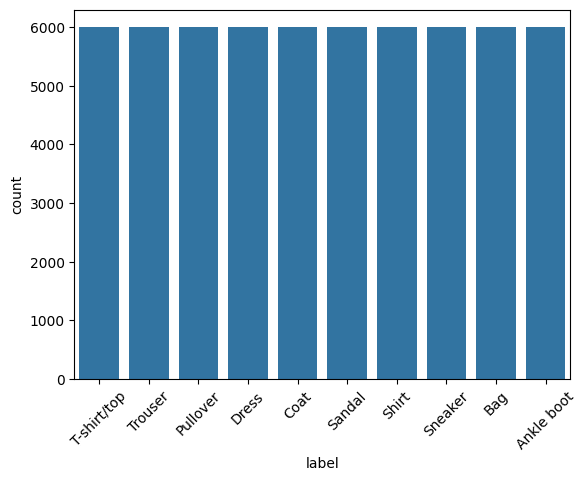

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

sns.countplot(x='label', data=df_train)
plt.xticks(ticks=range(10), labels=class_names, rotation=45)
plt.show()

In [ ]:
from sklearn.preprocessing import label_binarize

X = df_train.drop('label', axis = 1).values

X = X / 255 # Normalize to bring it between 0 - 1
y = df_train['label'].values

In [ ]:
X = X.reshape(-1,28,28,1)
y = to_categorical(y, 10)

In [ ]:
from sklearn.model_selection import train_test_split

X_train,X_val,y_train,y_val = train_test_split(X, y, test_size = 0.2, random_state=42)

X_test = df_test.drop('label',axis = 1).values
X_test = X_test / 255

X_test = X_test.reshape(-1, 28, 28, 1)

y_test = df_test['label'].values
y_test = to_categorical(y_test, 10)


In [ ]:
# visualize train images
def show_image(image_index):
    print(np.argmax(y_train[image_index]))
    plt.imshow(X_train[image_index,:,:,0], cmap='gray')
    plt.axis('off')
    plt.show()

# Create a slider widget
slider = widgets.IntSlider(value=0, min=0, max=len(X_train)-1, step=1)
widgets.interactive(show_image, image_index=slider)

interactive(children=(IntSlider(value=0, description='image_index', max=47999), Output()), _dom_classes=('widg…

In [ ]:
# Model

inputs = layers.Input(shape=(28,28,1), name ='input_layer')
# First Convolutional Block

x = layers.Conv2D(filters = 32, kernel_size = (3,3), strides = (1,1), padding = 'same',
                  activation = ('relu'), name = 'conv1')(inputs)
x = layers.MaxPooling2D(pool_size = (2,2), strides = (2,2), padding = 'valid', name = 'max_pool1')(x)

# Second Convolutional Block

x = layers.Conv2D(filters = 64, kernel_size = (3,3), strides = (1,1), padding = 'same',
                  activation = ('relu'), name = 'conv2')(x)
x = layers.MaxPooling2D(pool_size = (2,2), strides = (2,2), padding = 'valid', name = 'max_pool2')(x)

x = layers.Flatten()(x)
# Third Convolutional Block
x = layers.Dense(units = 128, activation='relu', name = 'dense1')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(units = 10, activation='softmax', name = 'dense2')(x)

# Create the model
model = models.Model(inputs= inputs, outputs= outputs, name='FashionMNIST')

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

Model: "FashionMNIST"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool1 (MaxPooling2D)        │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool2 (MaxPooling2D)        │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

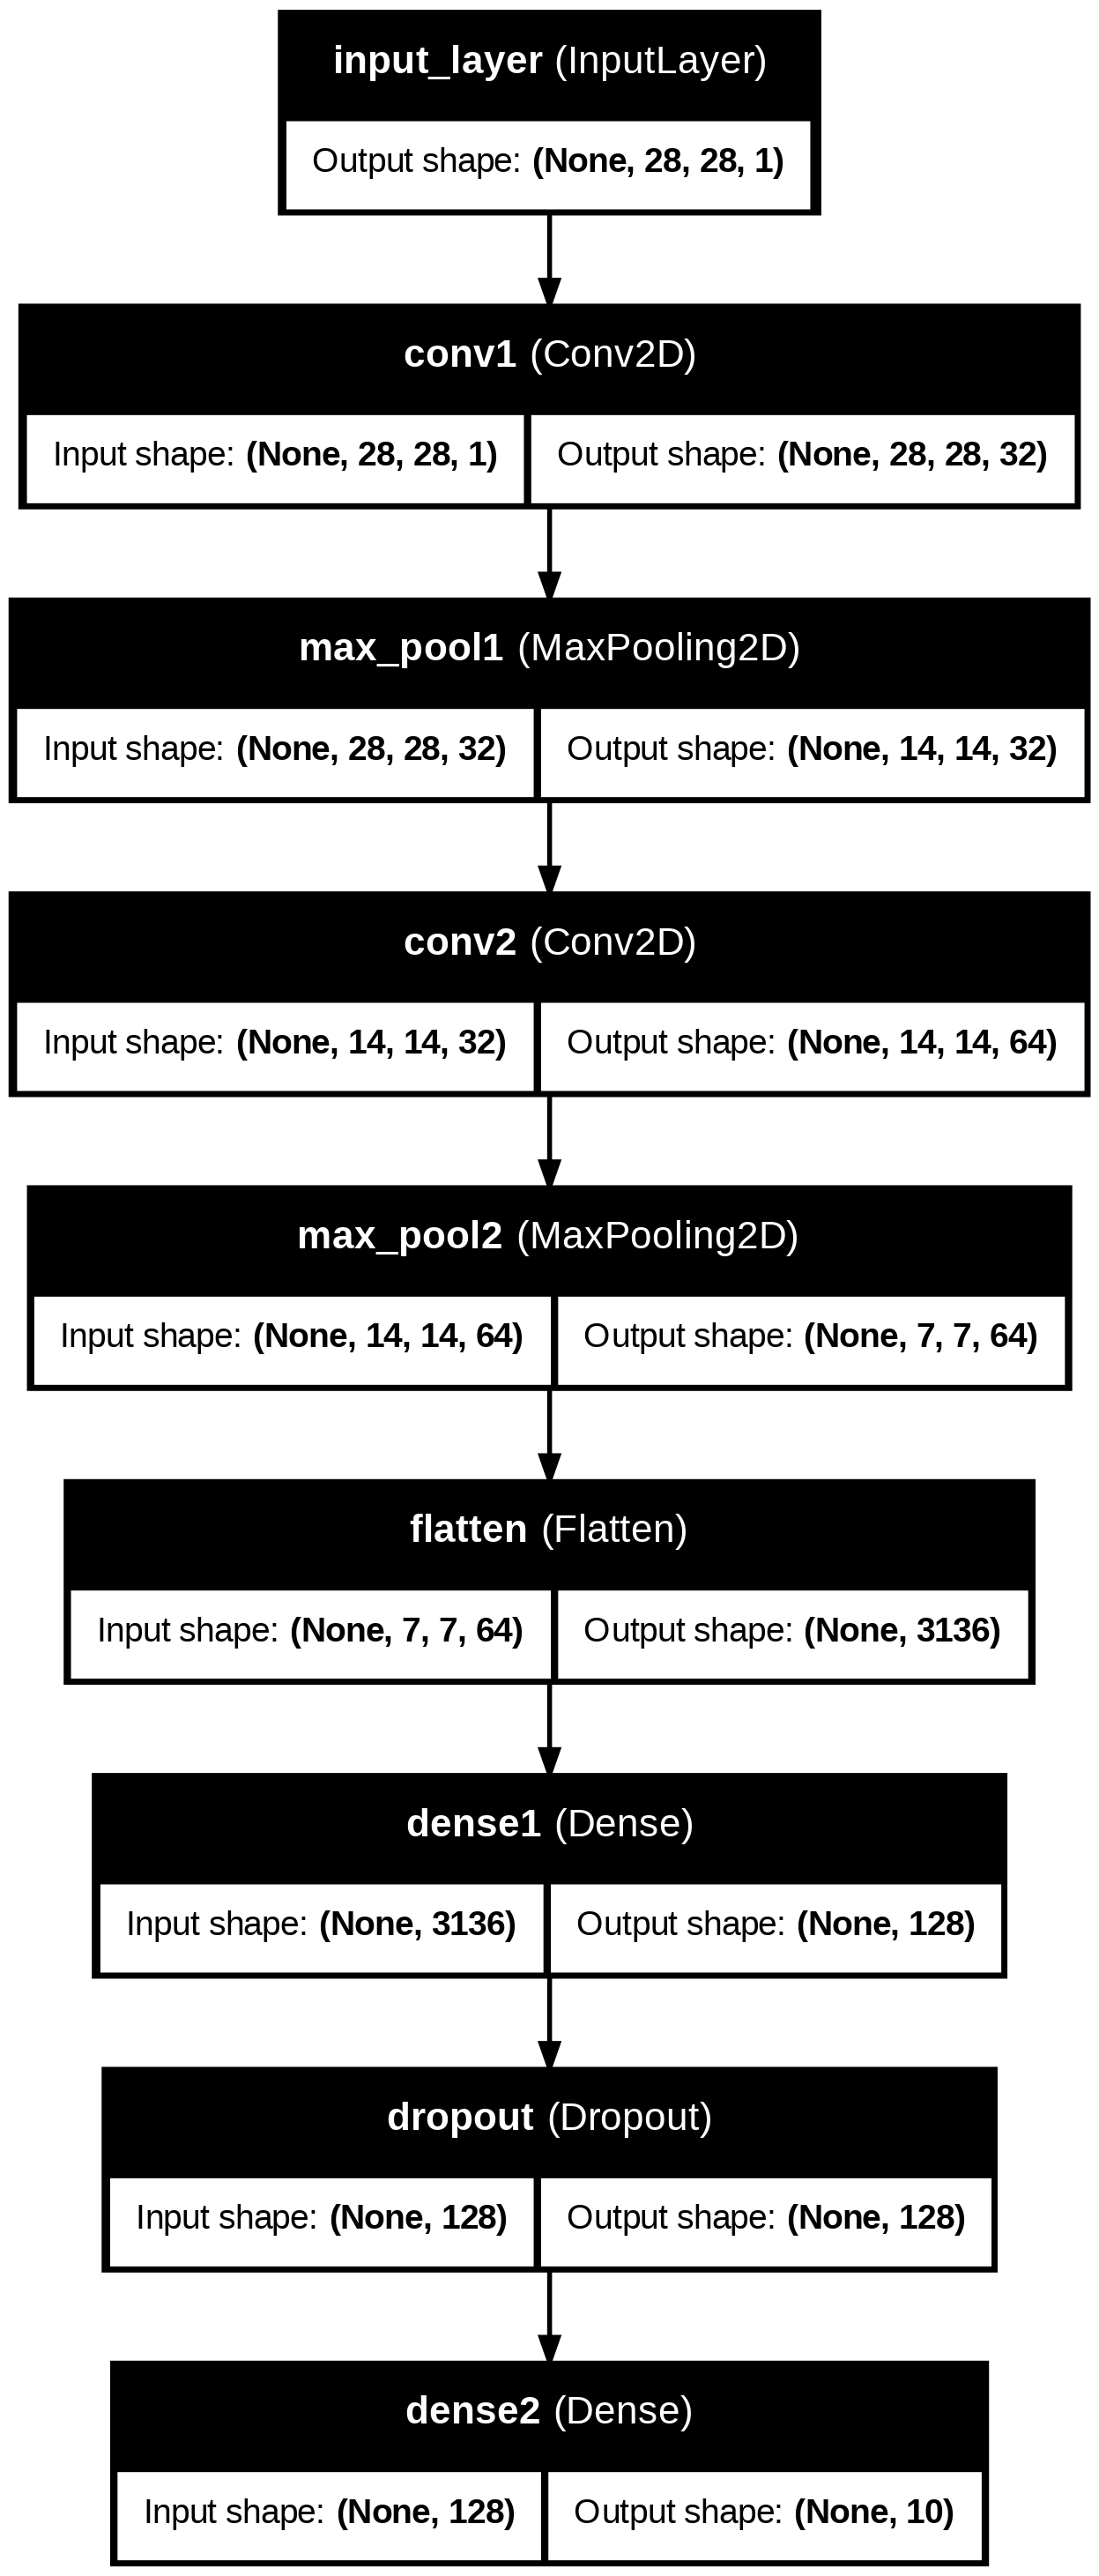

In [ ]:
plot_model(model, to_file='model_diagram.png', show_shapes=True, show_layer_names=True)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
# Train the model
history = model.fit(
    X_train,
    y_train,
    batch_size=32,
    epochs=20,
    validation_data=(X_val, y_val),
    shuffle=True
)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9336 - loss: 0.1767 - val_accuracy: 0.9228 - val_loss: 0.2203
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9390 - loss: 0.1624 - val_accuracy: 0.9215 - val_loss: 0.2317
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9431 - loss: 0.1549 - val_accuracy: 0.9237 - val_loss: 0.2453
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9456 - loss: 0.1428 - val_accuracy: 0.9247 - val_loss: 0.2429
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9476 - loss: 0.1383 - val_accuracy: 0.9250 - val_loss: 0.2517
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9506 - loss: 0.1317 - val_accuracy: 0.9246 - val_loss: 0.2579
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9516 - loss: 0.1226 - val_accuracy: 0.9253 - val_loss: 0.2517
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9549 - loss: 0.1163 - 

In [ ]:
from sklearn.metrics import mean_squared_error, accuracy_score
import numpy as np

# Make predictions on the test data
y_pred_prob = model.predict(X_test)
test_preds_round = np.argmax(y_pred_prob, axis=1);

# Convert one-hot encoded y_test back to single labels
test_labels = np.argmax(y_test, axis=1);

# ACCURACY
acc = accuracy_score(test_labels, test_preds_round)
print("Accuracy:", acc);


# MSE
mse = mean_squared_error(y_test, y_pred_prob)
print("Mean Squared Error:", mse);

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Accuracy: 0.9242
Mean Squared Error: 0.012046141697322137


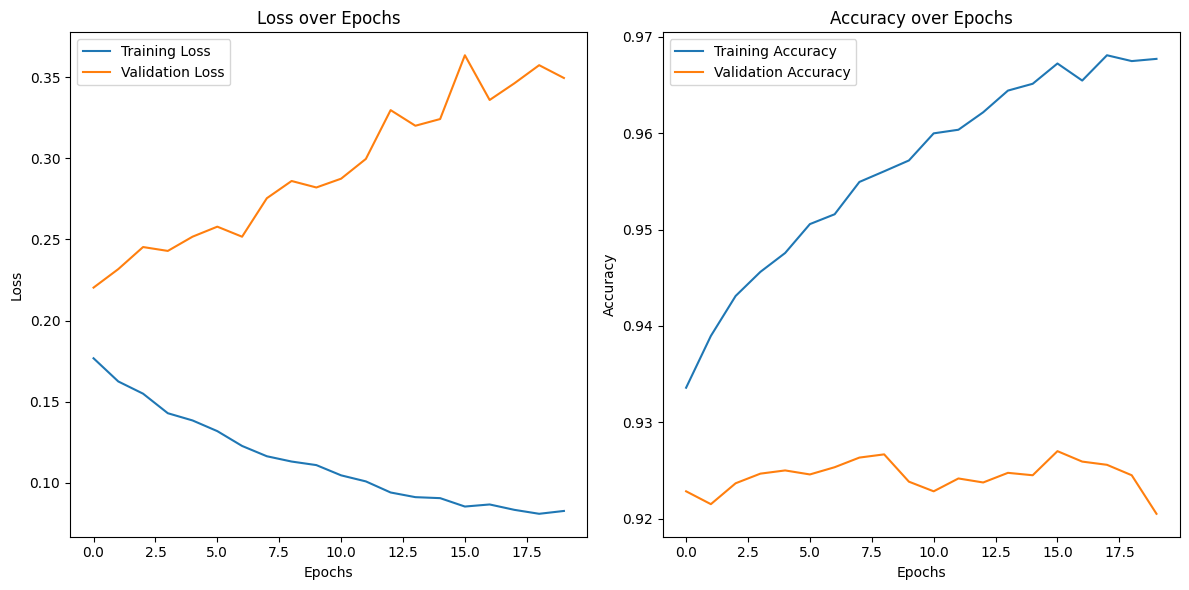

In [ ]:
# Extract loss and accuracy for training and validation
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

# Plotting Loss
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)  # Create a subplot for loss
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plotting Accuracy
plt.subplot(1, 2, 2)  # Create a subplot for accuracy
plt.plot(train_accuracy, label='Training Accuracy')
plt.plot(val_accuracy, label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Display the plots
plt.tight_layout()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


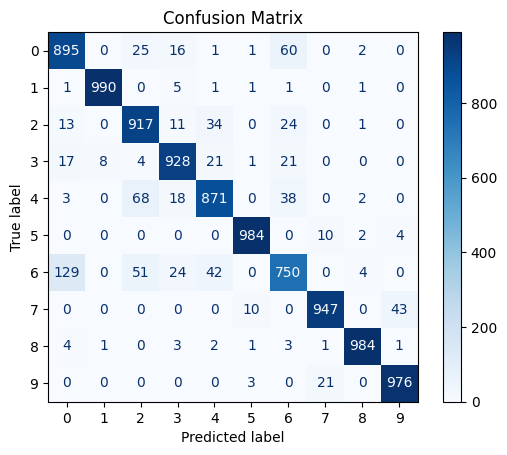

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Make predictions on the test data
y_pred_prob = model.predict(X_test)
test_preds_round = np.argmax(y_pred_prob, axis=1)

# Convert one-hot encoded y_test back to single labels
test_labels = np.argmax(y_test, axis=1)

# Compute confusion matrix
cm = confusion_matrix(test_labels, test_preds_round)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(10))
disp.plot(cmap='Blues')

plt.title("Confusion Matrix")
plt.show()

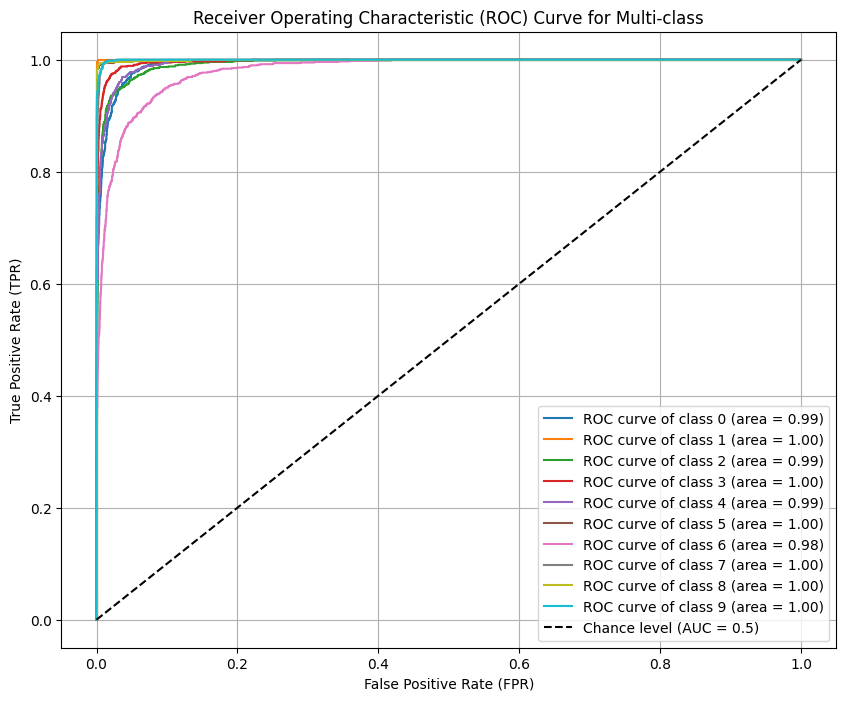

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Number of classes
n_classes = y_test.shape[1]

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(10, 8))

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'ROC curve of class {i} (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Chance level (AUC = 0.5)')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve for Multi-class')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


# Custom CNN

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalize
X_train = X_train / 255.0
X_test  = X_test / 255.0

# Reshape
X_train = X_train.reshape(-1, 28, 28, 1)
X_test  = X_test.reshape(-1, 28, 28, 1)

# One-hot encoding
y_train_cat = to_categorical(y_train, 10)
y_test_cat  = to_categorical(y_test, 10)


# BUILD CUSTOM CNN MODEL

model = models.Sequential([

    # Block 1
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    # Block 2
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    # Block 3
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    # Fully Connected
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(10, activation='softmax')
])


# COMPILE MODEL

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


# CALLBACKS

callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.3, patience=2)
]


# TRAIN MODEL
history = model.fit(
    X_train, y_train_cat,
    epochs=28,
    batch_size=64,
    validation_split=0.2,
    callbacks=callbacks,
    shuffle=True
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 24, 24, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 10, 10, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 10, 10, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 2, 2, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 2, 2, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 158,058 (617.41 KB)

 Trainable params: 157,354 (614.66 KB)

 Non-trainable params: 704 (2.75 KB)

Epoch 1/28
750/750 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - accuracy: 0.7397 - loss: 0.7218 - val_accuracy: 0.8364 - val_loss: 0.4339 - learning_rate: 0.0010
Epoch 2/28
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8422 - loss: 0.4388 - val_accuracy: 0.8558 - val_loss: 0.3883 - learning_rate: 0.0010
Epoch 3/28
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8711 - loss: 0.3636 - val_accuracy: 0.8926 - val_loss: 0.2962 - learning_rate: 0.0010
Epoch 4/28
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8794 - loss: 0.3313 - val_accuracy: 0.8997 - val_loss: 0.2752 - learning_rate: 0.0010
Epoch 5/28
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8870 - loss: 0.3093 - val_accuracy: 0.8887 - val_loss: 0.2960 - learning_rate: 0.0010
Epoch 6/28
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8962 - loss: 0.2882 - val_accuracy: 0.9053 - val_loss: 0.2482 - learning_rate: 0.0010
Epoch 7/28
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9005 - loss: 0.2781 -

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


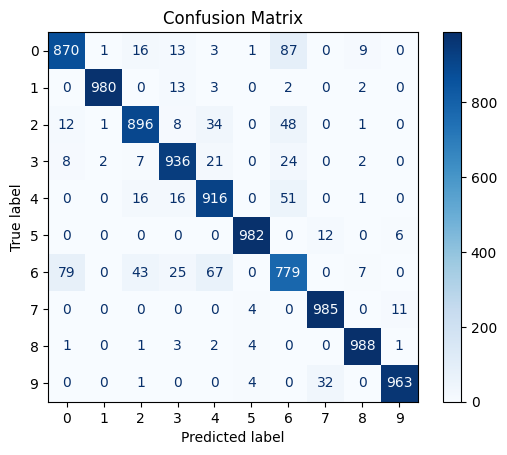

In [ ]:

# CONFUSION MATRIX

y_pred = np.argmax(model.predict(X_test), axis=1)

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9295 - loss: 0.2063
Test Accuracy: 0.9294999837875366


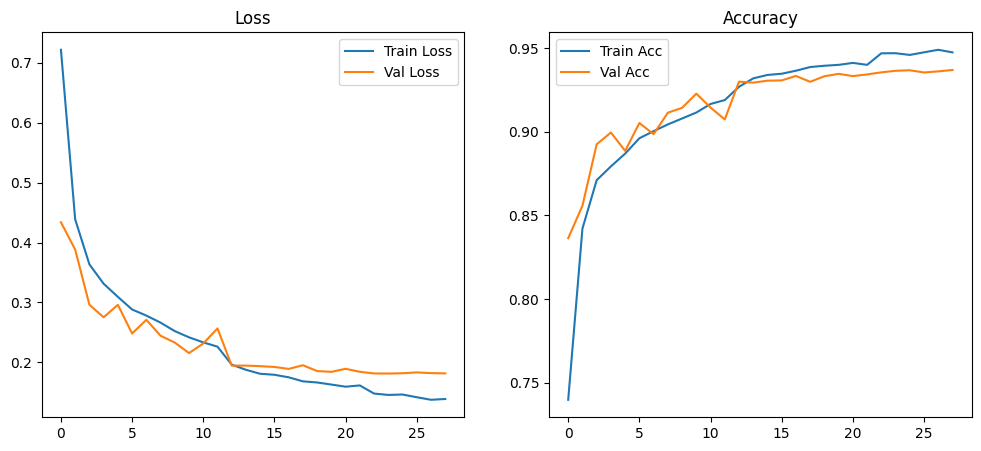

In [ ]:

# EVALUATION

test_loss, test_acc = model.evaluate(X_test, y_test_cat)
print("Test Accuracy:", test_acc)

# PLOT ACCURACY & LOSS

train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Val Loss')
plt.title("Loss")
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(train_acc, label='Train Acc')
plt.plot(val_acc, label='Val Acc')
plt.title("Accuracy")
plt.legend()

plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


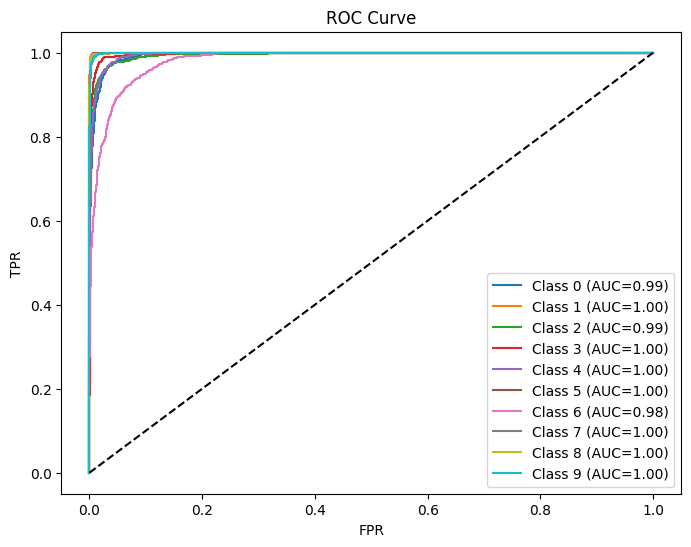

In [ ]:

# ROC CURVE (MULTI-CLASS)

y_test_bin = label_binarize(y_test, classes=range(10))
y_pred_prob = model.predict(X_test)

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(10):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8,6))
for i in range(10):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC={roc_auc[i]:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curve")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.show()

# Modified Custom CNN

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight


train_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Fashion_MNIST/fashion-mnist_train.csv")
test_df  = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Fashion_MNIST/fashion-mnist_test.csv")

# First column = label
y_train = train_df.iloc[:, 0].values
X_train = train_df.iloc[:, 1:].values

y_test = test_df.iloc[:, 0].values
X_test = test_df.iloc[:, 1:].values

# Normalize
X_train = X_train / 255.0
X_test  = X_test / 255.0

# Reshape
X_train = X_train.reshape(-1, 28, 28, 1)
X_test  = X_test.reshape(-1, 28, 28, 1)

# KEEP ORIGINAL LABELS FOR CLASS WEIGHTS
y_train_labels = y_train.copy()

# One-hot encoding
y_train_encoded = to_categorical(y_train, 10)
y_test_encoded  = to_categorical(y_test, 10)

# CLASS WEIGHTS

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_labels),
    y=y_train_labels
)

class_weights_dict = dict(enumerate(class_weights))
print("Class Weights:", class_weights_dict)


# BUILD CUSTOM CNN MODEL

model = models.Sequential([

    # Block 1
    layers.Conv2D(32, (3,3), padding='same', input_shape=(28,28,1)),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.Conv2D(32, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    # Block 2
    layers.Conv2D(64, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.Conv2D(64, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    # Block 3
    layers.Conv2D(128, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    # Fully Connected
    layers.Flatten(),

    layers.Dense(128),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.3),

    layers.Dense(10, activation='softmax')
])



# COMPILE MODEL

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()



# CALLBACKS

callbacks = [

    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=2,
        min_lr=1e-5,
        verbose=1
    )
]



# TRAIN MODEL

history = model.fit(
    X_train, y_train_encoded,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weights_dict,
    callbacks=callbacks,
    shuffle=True
)

Class Weights: {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.0), 4: np.float64(1.0), 5: np.float64(1.0), 6: np.float64(1.0), 7: np.float64(1.0), 8: np.float64(1.0), 9: np.float64(1.0)}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 289,514 (1.10 MB)

 Trainable params: 288,618 (1.10 MB)

 Non-trainable params: 896 (3.50 KB)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step - accuracy: 0.8120 - loss: 0.5158 - val_accuracy: 0.8934 - val_loss: 0.2952 - learning_rate: 0.0010
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8773 - loss: 0.3363 - val_accuracy: 0.9037 - val_loss: 0.2665 - learning_rate: 0.0010
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8930 - loss: 0.2954 - val_accuracy: 0.9042 - val_loss: 0.2500 - learning_rate: 0.0010
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8999 - loss: 0.2741 - val_accuracy: 0.9105 - val_loss: 0.2358 - learning_rate: 0.0010
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9074 - loss: 0.2547 - val_accuracy: 0.9103 - val_loss: 0.2381 - learning_rate: 0.0010
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9128 - loss: 0.2405 - val_accuracy: 0.9187 - val_loss: 0.2188 - learning_rate: 0.0010
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9156 -

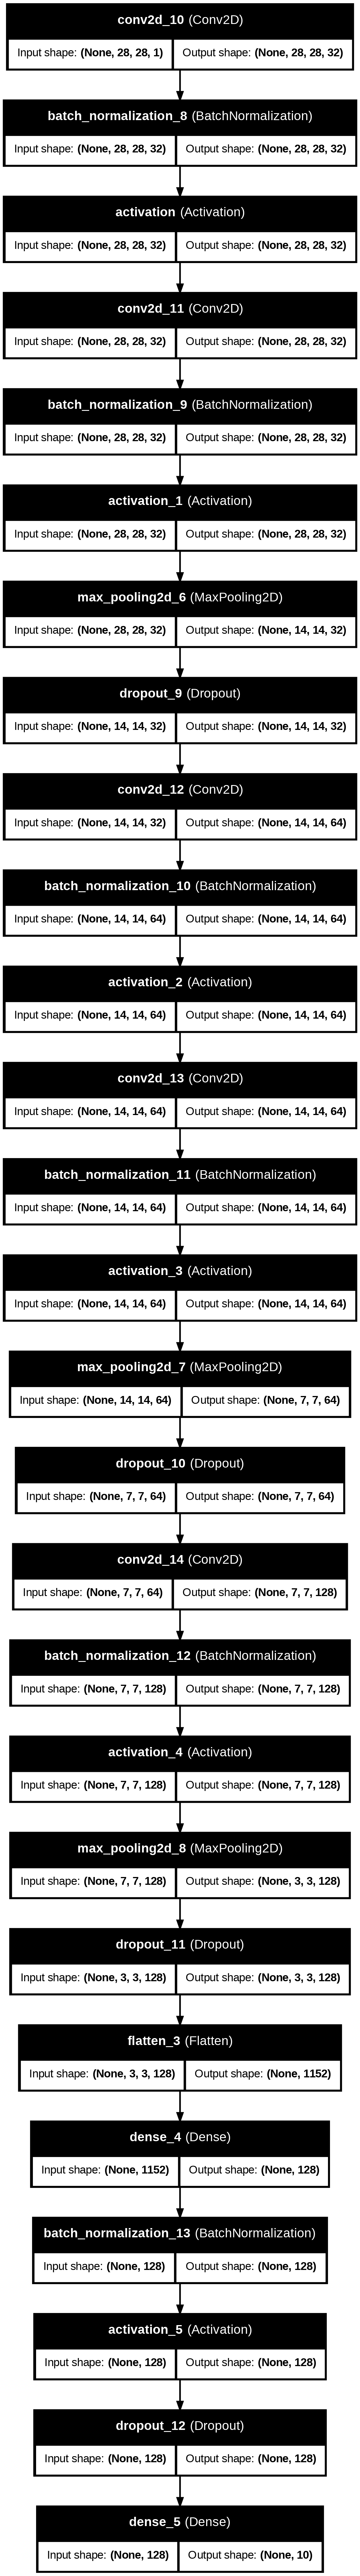

In [ ]:
from tensorflow.keras.utils import plot_model
plot_model(model, to_file='model_diagram.png', show_shapes=True, show_layer_names=True)

In [ ]:
# EVALUATE

test_loss, test_acc = model.evaluate(X_test, y_test_encoded)

print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9326 - loss: 0.1802
Test Accuracy: 0.9326000213623047


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


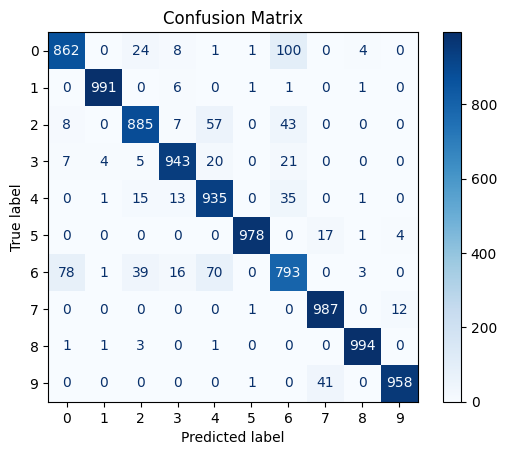

In [ ]:
# CONFUSION MATRIX

# Make predictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

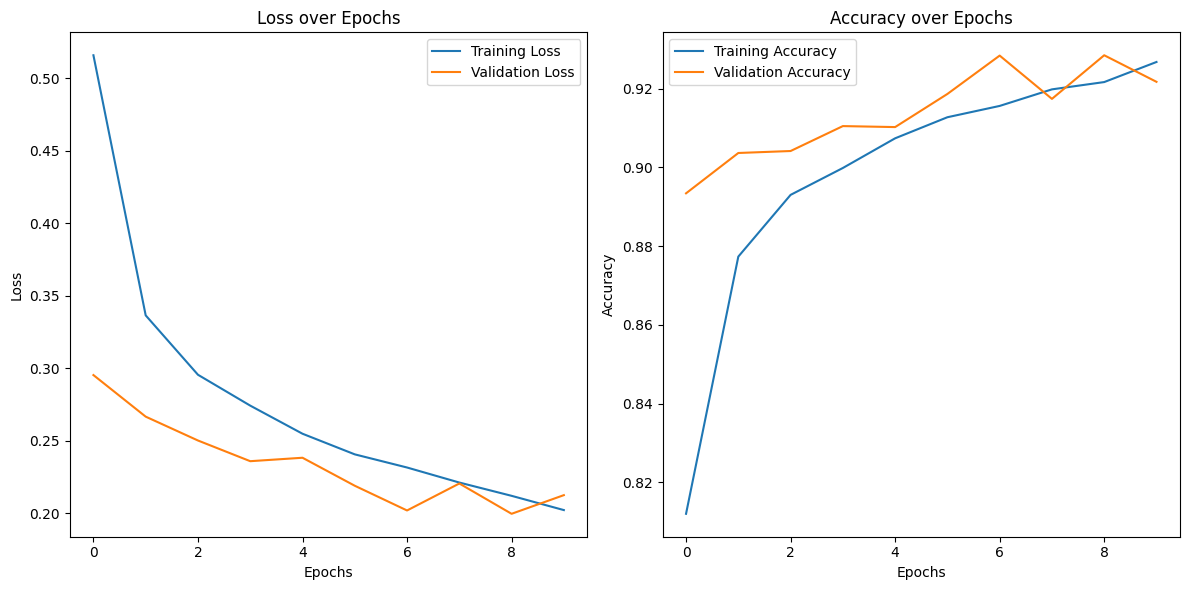

In [ ]:
# Extract loss and accuracy for training and validation
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

# Plotting Loss
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)  # Create a subplot for loss
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plotting Accuracy
plt.subplot(1, 2, 2)  # Create a subplot for accuracy
plt.plot(train_accuracy, label='Training Accuracy')
plt.plot(val_accuracy, label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Display the plots
plt.tight_layout()
plt.show()

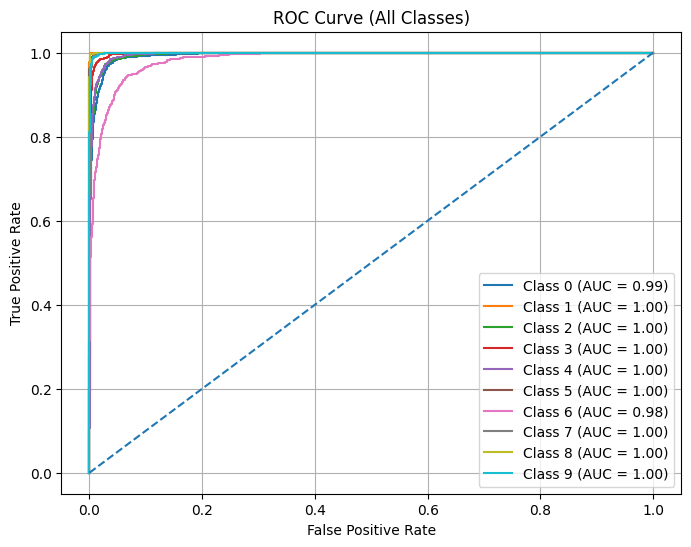

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np
import matplotlib.pyplot as plt

# Number of classes
n_classes = 10 # Fashion MNIST has 10 classes

# Binarize the true labels
y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8,6))

for i in range(10):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

# Random classifier line
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (All Classes)")
plt.legend(loc="lower right")
plt.grid()
plt.show()

# AlexNet

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

train_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Fashion_MNIST/fashion-mnist_train.csv")
test_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Fashion_MNIST/fashion-mnist_test.csv")

y_train = train_df.iloc[:, 0].values
x_train = train_df.iloc[:, 1:].values

y_test = test_df.iloc[:, 0].values
x_test = test_df.iloc[:, 1:].values


# PREPROCESS

x_train = x_train.reshape(-1, 28, 28, 1).astype("float32") / 255.0
x_test = x_test.reshape(-1, 28, 28, 1).astype("float32") / 255.0

y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)


# TF.DATA PIPELINE

train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train)) \
    .shuffle(10000) \
    .batch(64) \
    .prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test)) \
    .batch(64) \
    .prefetch(tf.data.AUTOTUNE)


# LIGHT ALEXNET MODEL

def light_alexnet(input_shape=(28,28,1), num_classes=10):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        # Conv Block 1
        layers.Conv2D(32, (3,3), strides=1, padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D((2,2)),

        # Conv Block 2
        layers.Conv2D(64, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D((2,2)),

        # Conv Block 3
        layers.Conv2D(128, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),

        layers.Conv2D(128, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D((2,2)),

        layers.Flatten(),

        # Fully Connected
        layers.Dense(256),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.Dropout(0.5),

        layers.Dense(128),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.Dropout(0.5),

        layers.Dense(num_classes, activation='softmax')
    ])
    return model

model = light_alexnet()


# CALLBACKS

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2,
    min_lr=1e-6
)


# COMPILE

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


# TRAIN

history = model.fit(
    train_ds,
    epochs=10,
    validation_data=test_ds,
    callbacks=[early_stop, reduce_lr],
    shuffle=True

)

Mounted at /content/drive
Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.8298 - loss: 0.4987 - val_accuracy: 0.8891 - val_loss: 0.2955 - learning_rate: 0.0010
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8929 - loss: 0.3118 - val_accuracy: 0.9102 - val_loss: 0.2349 - learning_rate: 0.0010
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9069 - loss: 0.2718 - val_accuracy: 0.9105 - val_loss: 0.2479 - learning_rate: 0.0010
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9175 - loss: 0.2364 - val_accuracy: 0.9164 - val_loss: 0.2297 - learning_rate: 0.0010
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9229 - loss: 0.2175 - val_accuracy: 0.9093 - val_loss: 0.2471 - learning_rate: 0.0010
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9299 - loss: 0.1962 - val_accuracy: 0.9280 - val_loss: 0.2013 - learning_rate: 0.0010
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accu

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


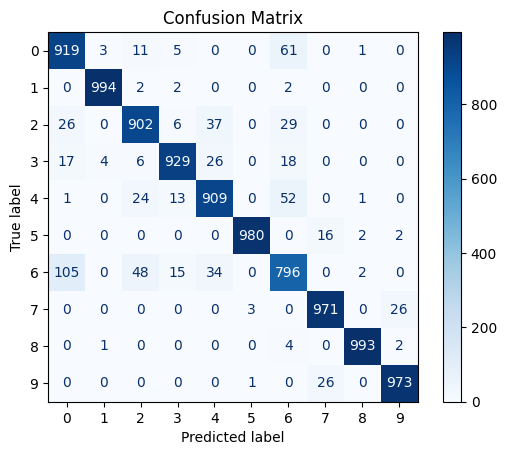

In [ ]:
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(np.argmax(y_test, axis=1), y_pred)
ConfusionMatrixDisplay(cm).plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

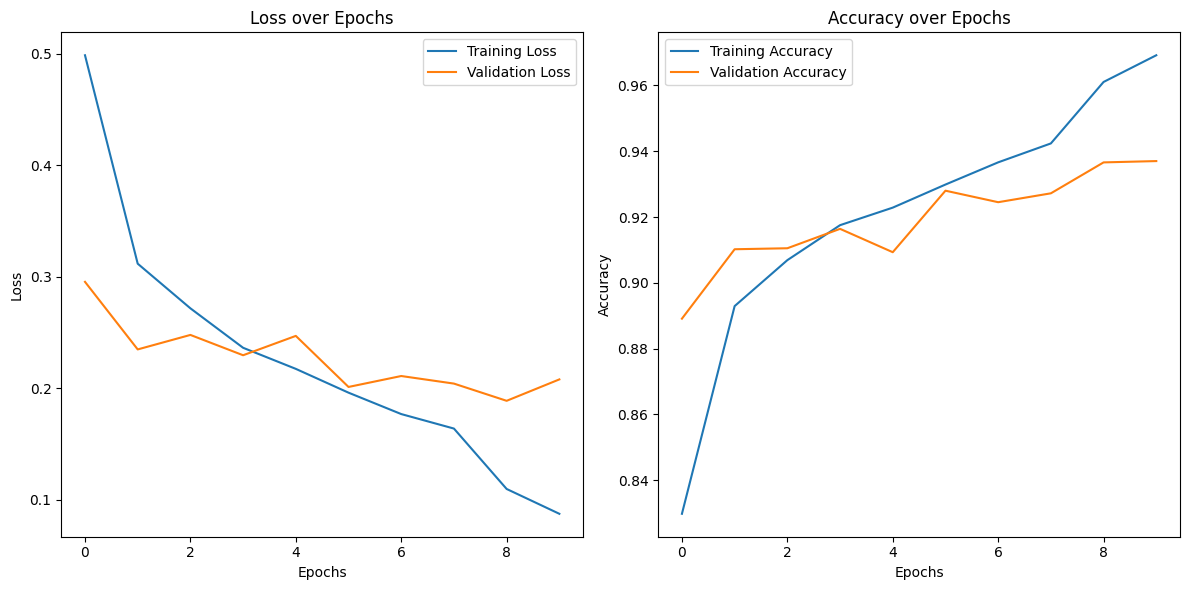

In [ ]:
# Extract loss and accuracy for training and validation
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

# Plotting Loss
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)  # Create a subplot for loss
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plotting Accuracy
plt.subplot(1, 2, 2)  # Create a subplot for accuracy
plt.plot(train_accuracy, label='Training Accuracy')
plt.plot(val_accuracy, label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Display the plots
plt.tight_layout()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


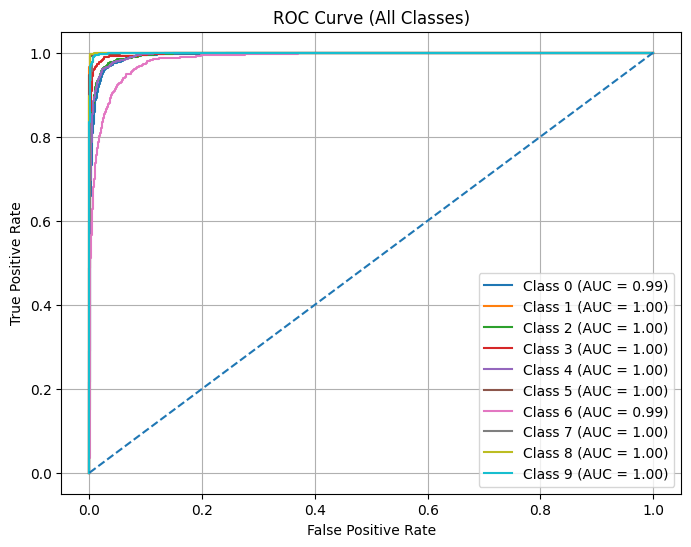

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Make predictions with the AlexNet model
y_pred_probs = model.predict(x_test)

# Binarize the true labels
n_classes = y_test.shape[1] # Number of classes
y_test_bin = y_test

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8,6))

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

# Random classifier line
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (All Classes)")
plt.legend(loc="lower right")
plt.grid()
plt.show()

# Lenet Without Pretrained weights just only Lenet Architecture but with Data Augmentation & shuffling

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

train_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Fashion_MNIST/fashion-mnist_train.csv")
test_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Fashion_MNIST/fashion-mnist_test.csv")

y_train = train_df.iloc[:, 0].values
x_train = train_df.iloc[:, 1:].values

y_test = test_df.iloc[:, 0].values
x_test = test_df.iloc[:, 1:].values


# PREPROCESS

x_train = x_train.reshape(-1, 28, 28, 1).astype("float32") / 255.0
x_test = x_test.reshape(-1, 28, 28, 1).astype("float32") / 255.0

y_train_cat = tf.keras.utils.to_categorical(y_train, 10)
y_test_cat = tf.keras.utils.to_categorical(y_test, 10)


# DATA AUGMENTATION LAYER

data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.1),
    layers.RandomTranslation(0.1, 0.1),
])


# DATA PIPELINE

def preprocess(image, label):
    image = data_augmentation(image, training=True)  # apply only on training
    return image, label

# TRAIN DATA (with shuffle + augmentation)
train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train_cat))
train_ds = train_ds.shuffle(10000) \
                   .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE) \
                   .batch(32) \
                   .prefetch(tf.data.AUTOTUNE)

# TEST DATA (NO augmentation, NO shuffle)
def preprocess_test(image, label):
    return image, label

test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test_cat))
test_ds = test_ds.map(preprocess_test) \
                 .batch(32) \
                 .prefetch(tf.data.AUTOTUNE)


# LENET MODEL

def lenet_model(input_shape=(28,28,1), num_classes=10):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(6, (5,5), activation='tanh'),
        layers.AveragePooling2D(pool_size=(2,2)),

        layers.Conv2D(16, (5,5), activation='tanh'),
        layers.AveragePooling2D(pool_size=(2,2)),

        layers.Flatten(),

        layers.Dense(120, activation='tanh'),
        layers.Dense(84, activation='tanh'),

        layers.Dense(num_classes, activation='softmax')
    ])
    return model

model = lenet_model()


# COMPILE

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


# TRAIN

history = model.fit(
    train_ds,
    epochs=5,
    validation_data=test_ds
)

Mounted at /content/drive
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 50s 25ms/step - accuracy: 0.6616 - loss: 0.8969 - val_accuracy: 0.7378 - val_loss: 0.6711
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 80s 25ms/step - accuracy: 0.7381 - loss: 0.6859 - val_accuracy: 0.7901 - val_loss: 0.5510
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 46s 25ms/step - accuracy: 0.7612 - loss: 0.6257 - val_accuracy: 0.8025 - val_loss: 0.5287
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 47s 25ms/step - accuracy: 0.7729 - loss: 0.5915 - val_accuracy: 0.8002 - val_loss: 0.5158
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 45s 24ms/step - accuracy: 0.7831 - loss: 0.5692 - val_accuracy: 0.7991 - val_loss: 0.5118


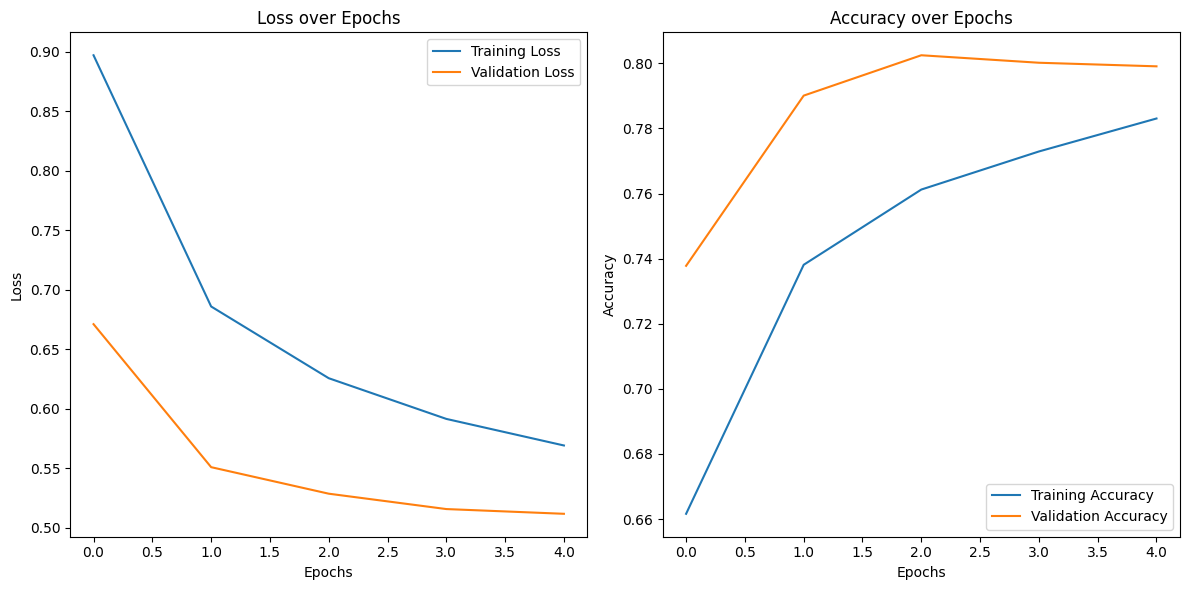

In [ ]:
# Extract loss and accuracy for training and validation
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

# Plotting Loss
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)  # Create a subplot for loss
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plotting Accuracy
plt.subplot(1, 2, 2)  # Create a subplot for accuracy
plt.plot(train_accuracy, label='Training Accuracy')
plt.plot(val_accuracy, label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Display the plots
plt.tight_layout()
plt.show()

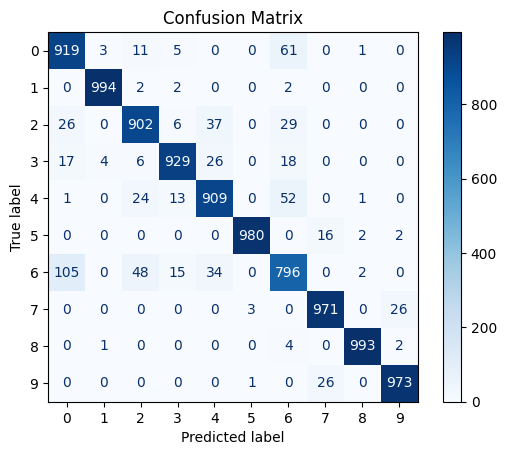

In [ ]:
# CONFUSION MATRIX

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

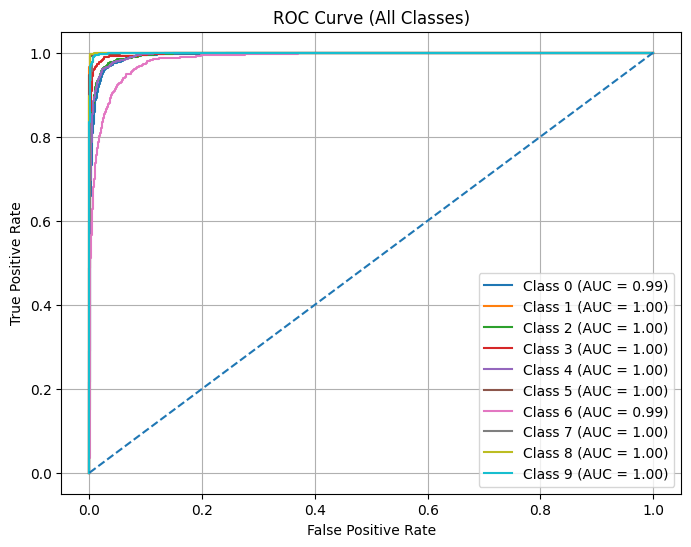

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize the true labels
y_test_bin = label_binarize(y_test, classes=range(10))

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(10):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8,6))

for i in range(10):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

# Random classifier line
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (All Classes)")
plt.legend(loc="lower right")
plt.grid()
plt.show()

# LeNet Without Shuffling & data Augmentation

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize


from google.colab import drive
drive.mount('/content/drive', force_remount=True)

train_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Fashion_MNIST/fashion-mnist_train.csv")
test_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Fashion_MNIST/fashion-mnist_test.csv")

y_train = train_df.iloc[:, 0].values
x_train = train_df.iloc[:, 1:].values

y_test = test_df.iloc[:, 0].values
x_test = test_df.iloc[:, 1:].values

# Reshape + normalize
x_train = x_train.reshape(-1, 28, 28, 1).astype("float32") / 255.0
x_test = x_test.reshape(-1, 28, 28, 1).astype("float32") / 255.0

# One-hot encoding
y_train_cat = tf.keras.utils.to_categorical(y_train, 10)
y_test_cat = tf.keras.utils.to_categorical(y_test, 10)

# DATA PIPELINE

def preprocess(image, label):
    return image, label

train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train_cat))
train_ds = train_ds.map(preprocess).batch(32).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test_cat))
test_ds = test_ds.map(preprocess).batch(32).prefetch(tf.data.AUTOTUNE)


# LENET MODEL

def lenet_model(input_shape=(28,28,1), num_classes=10):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(6, (5,5), activation='tanh'),
        layers.AveragePooling2D(pool_size=(2,2)),

        layers.Conv2D(16, (5,5), activation='tanh'),
        layers.AveragePooling2D(pool_size=(2,2)),

        layers.Flatten(),

        layers.Dense(120, activation='tanh'),
        layers.Dense(84, activation='tanh'),

        layers.Dense(num_classes, activation='softmax')
    ])
    return model

model = lenet_model()


# COMPILE

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


# TRAIN

history = model.fit(
    train_ds,
    epochs=5,
    validation_data=test_ds
)


# EVALUATE
test_loss, test_acc = model.evaluate(test_ds)
print("Test Accuracy:", test_acc)


Mounted at /content/drive
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.7930 - loss: 0.5603 - val_accuracy: 0.8301 - val_loss: 0.4637
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8530 - loss: 0.4027 - val_accuracy: 0.8423 - val_loss: 0.4216
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8680 - loss: 0.3588 - val_accuracy: 0.8529 - val_loss: 0.3849
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8793 - loss: 0.3291 - val_accuracy: 0.8640 - val_loss: 0.3630
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8875 - loss: 0.3065 - val_accuracy: 0.8712 - val_loss: 0.3470
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8712 - loss: 0.3470
Test Accuracy: 0.8712000250816345


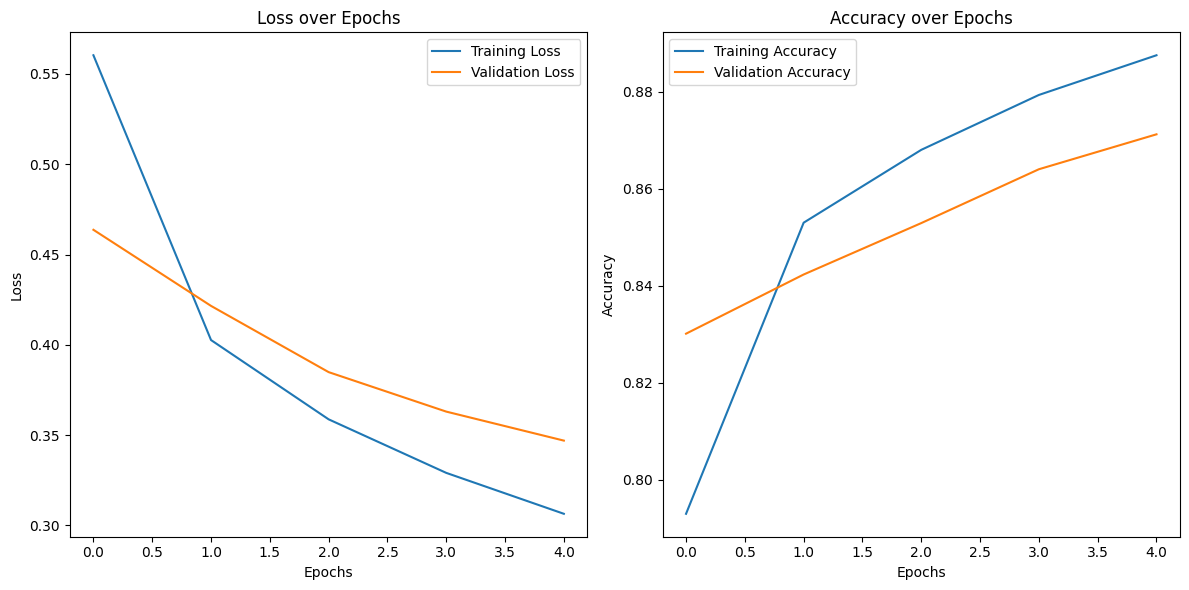

In [ ]:
# Extract loss and accuracy for training and validation
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

# Plotting Loss
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)  # Create a subplot for loss
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plotting Accuracy
plt.subplot(1, 2, 2)  # Create a subplot for accuracy
plt.plot(train_accuracy, label='Training Accuracy')
plt.plot(val_accuracy, label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Display the plots
plt.tight_layout()
plt.show()

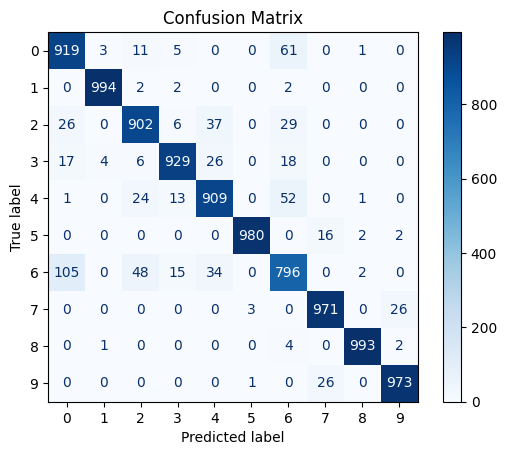

In [ ]:
# CONFUSION MATRIX

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

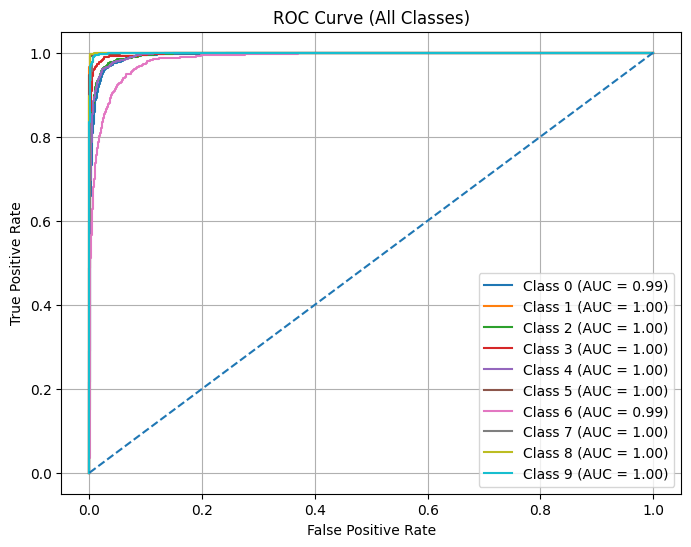

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize the true labels
y_test_bin = label_binarize(y_test, classes=range(10))

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(10):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8,6))

for i in range(10):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

# Random classifier line
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (All Classes)")
plt.legend(loc="lower right")
plt.grid()
plt.show()

# Using Pretrained weights for EfficientNet

In [ ]:
# # ==============================
# # 1. IMPORTS
# # ==============================
# import tensorflow as tf
# from tensorflow.keras import layers, models
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt

# from tensorflow.keras.applications import EfficientNetB0
# from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# from sklearn.metrics import roc_curve, auc
# from sklearn.preprocessing import label_binarize

# # ==============================
# # 2. LOAD CSV DATA
# # ==============================
# train_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Fashion_MNIST/fashion-mnist_train.csv")
# test_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Fashion_MNIST/fashion-mnist_test.csv")

# y_train = train_df.iloc[:, 0].values
# x_train = train_df.iloc[:, 1:].values

# y_test = test_df.iloc[:, 0].values
# x_test = test_df.iloc[:, 1:].values

# # Reshape + normalize
# x_train = x_train.reshape(-1, 28, 28, 1).astype("float32") / 255.0
# x_test = x_test.reshape(-1, 28, 28, 1).astype("float32") / 255.0

# # One-hot encoding
# y_train_cat = tf.keras.utils.to_categorical(y_train, 10)
# y_test_cat = tf.keras.utils.to_categorical(y_test, 10)

# # ==============================
# # 3. PREPROCESS (FOR EFFICIENTNET)
# # ==============================
# def preprocess(image, label):
#     image = tf.image.resize(image, (224, 224))
#     image = tf.image.grayscale_to_rgb(image)
#     return image, label

# train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train_cat))
# train_ds = train_ds.map(preprocess).batch(32).prefetch(tf.data.AUTOTUNE)

# test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test_cat))
# test_ds = test_ds.map(preprocess).batch(32).prefetch(tf.data.AUTOTUNE)

# # ==============================
# # 4. LOAD PRETRAINED EFFICIENTNET
# # ==============================
# base_model = EfficientNetB0(
#     weights='imagenet',
#     include_top=False,
#     input_shape=(224,224,3)
# )

# # Freeze pretrained layers
# base_model.trainable = False

# # ==============================
# # 5. ADD LENET-STYLE CLASSIFIER HEAD
# # ==============================
# model = models.Sequential([
#     base_model,

#     layers.GlobalAveragePooling2D(),

#     # LeNet-style dense layers
#     layers.Dense(120, activation='tanh'),
#     layers.Dense(84, activation='tanh'),

#     layers.Dense(10, activation='softmax')
# ])

# # ==============================
# # 6. COMPILE
# # ==============================
# model.compile(
#     optimizer='adam',
#     loss='categorical_crossentropy',
#     metrics=['accuracy']
# )

# # ==============================
# # 7. TRAIN
# # ==============================
# history = model.fit(
#     train_ds,
#     epochs=5,
#     validation_data=test_ds
# )

# # ==============================
# # 8. EVALUATE
# # ==============================
# test_loss, test_acc = model.evaluate(test_ds)
# print("Test Accuracy:", test_acc)

# # ==============================
# # 9. PREDICTIONS
# # ==============================
# y_pred_probs = model.predict(test_ds)
# y_pred = np.argmax(y_pred_probs, axis=1)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 129s 53ms/step - accuracy: 0.0985 - loss: 2.3182 - val_accuracy: 0.1000 - val_loss: 2.3112
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 79s 42ms/step - accuracy: 0.0991 - loss: 2.3135 - val_accuracy: 0.1000 - val_loss: 2.3112
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 83s 42ms/step - accuracy: 0.0991 - loss: 2.3134 - val_accuracy: 0.1000 - val_loss: 2.3111
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 79s 42ms/step - accuracy: 0.0991 - loss: 2.3134 - val_accuracy: 0.1000 - val_loss: 2.3111
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 79s 42ms/step - accuracy: 0.0990 - loss: 2.3134 - val_accuracy: 0.1000 - val_loss: 2.3112
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - accuracy: 0.1000 - loss: 2.3112
Test Accuracy: 0.10000000149011612
313/313 ━━━━━━━━━━━━━━━━━━━━ 25s 56ms/step


# MobileNet

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

train_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Fashion_MNIST/fashion-mnist_train.csv")
test_df  = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Fashion_MNIST/fashion-mnist_test.csv")

y_train = train_df.iloc[:, 0].values
x_train = train_df.iloc[:, 1:].values

y_test = test_df.iloc[:, 0].values
x_test = test_df.iloc[:, 1:].values


# PREPROCESSING

x_train = x_train.reshape(-1, 28, 28, 1).astype("float32") / 255.0
x_test  = x_test.reshape(-1, 28, 28, 1).astype("float32") / 255.0

y_train_cat = tf.keras.utils.to_categorical(y_train, 10)
y_test_cat  = tf.keras.utils.to_categorical(y_test, 10)


# CLASS WEIGHTS

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights_dict = dict(enumerate(class_weights))
print("Class Weights:", class_weights_dict)


# DATA PIPELINE (WITH SHUFFLE)

def preprocess(image, label):
    image = tf.image.resize(image, (96, 96))
    image = tf.image.grayscale_to_rgb(image)
    return image, label

train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train_cat))
train_ds = train_ds.shuffle(buffer_size=10000)
train_ds = train_ds.map(preprocess).batch(32).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test_cat))
test_ds = test_ds.map(preprocess).batch(32).prefetch(tf.data.AUTOTUNE)


# MODEL (MobileNetV2)

from tensorflow.keras.applications import MobileNetV2

def mobilenet_model(input_shape=(96,96,3), num_classes=10):
    base_model = MobileNetV2(
        weights=None,
        include_top=False,
        input_shape=input_shape
    )

    base_model.trainable = True

    model = models.Sequential([
        base_model,

        layers.GlobalAveragePooling2D(),

        layers.BatchNormalization(),
        layers.Dense(128, activation='relu'),

        layers.BatchNormalization(),
        layers.Dropout(0.4),

        layers.Dense(num_classes, activation='softmax')
    ])
    return model

model = mobilenet_model()


# COMPILE

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


# CALLBACKS

callbacks = [

    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]


# TRAIN

history = model.fit(
    train_ds,
    epochs=15,
    validation_data=test_ds,
    class_weight=class_weights_dict,
    callbacks=callbacks
)

Mounted at /content/drive
Class Weights: {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.0), 4: np.float64(1.0), 5: np.float64(1.0), 6: np.float64(1.0), 7: np.float64(1.0), 8: np.float64(1.0), 9: np.float64(1.0)}


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,428,874 (9.27 MB)

 Trainable params: 2,391,946 (9.12 MB)

 Non-trainable params: 36,928 (144.25 KB)

Epoch 1/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 118s 37ms/step - accuracy: 0.7887 - loss: 0.6137 - val_accuracy: 0.1000 - val_loss: 3.4180 - learning_rate: 0.0010
Epoch 2/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 62s 33ms/step - accuracy: 0.8735 - loss: 0.3655 - val_accuracy: 0.1000 - val_loss: 3.9213 - learning_rate: 0.0010
Epoch 3/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 62s 33ms/step - accuracy: 0.8882 - loss: 0.3209 - val_accuracy: 0.8975 - val_loss: 0.2885 - learning_rate: 0.0010
Epoch 4/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 61s 33ms/step - accuracy: 0.8964 - loss: 0.2973 - val_accuracy: 0.8046 - val_loss: 0.9864 - learning_rate: 0.0010
Epoch 5/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9017 - loss: 0.2810
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 61s 32ms/step - accuracy: 0.9046 - loss: 0.2742 - val_accuracy: 0.8370 - val_loss: 0.6759 - learning_rate: 0.0010
Epoch 6/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 63s 34ms/step - accurac

In [ ]:

# EVALUATE

test_loss, test_acc = model.evaluate(test_ds)
print("Test Accuracy:", test_acc)


# PREDICTIONS

y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9307 - loss: 0.1937
Test Accuracy: 0.9307000041007996
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step


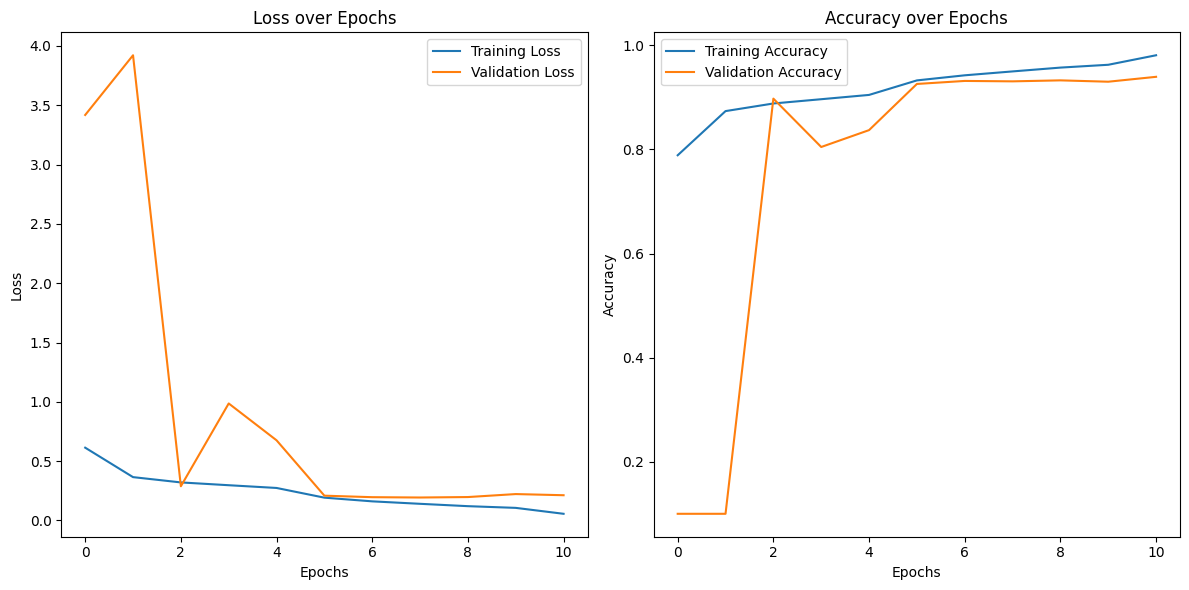

In [ ]:
# Extract loss and accuracy for training and validation
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

# Plotting Loss
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)  # Create a subplot for loss
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plotting Accuracy
plt.subplot(1, 2, 2)  # Create a subplot for accuracy
plt.plot(train_accuracy, label='Training Accuracy')
plt.plot(val_accuracy, label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Display the plots
plt.tight_layout()
plt.show()

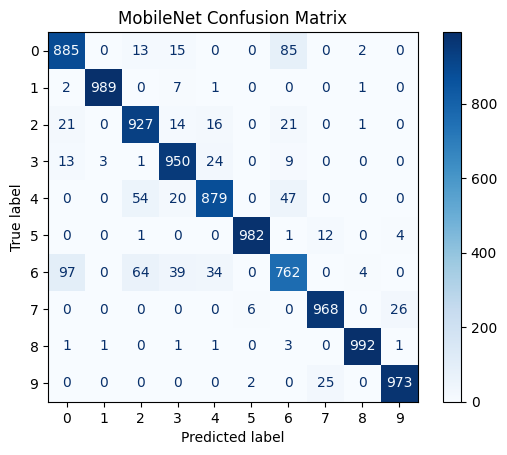

In [ ]:
# CONFUSION MATRIX

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot(cmap='Blues')
plt.title("MobileNet Confusion Matrix")
plt.show()

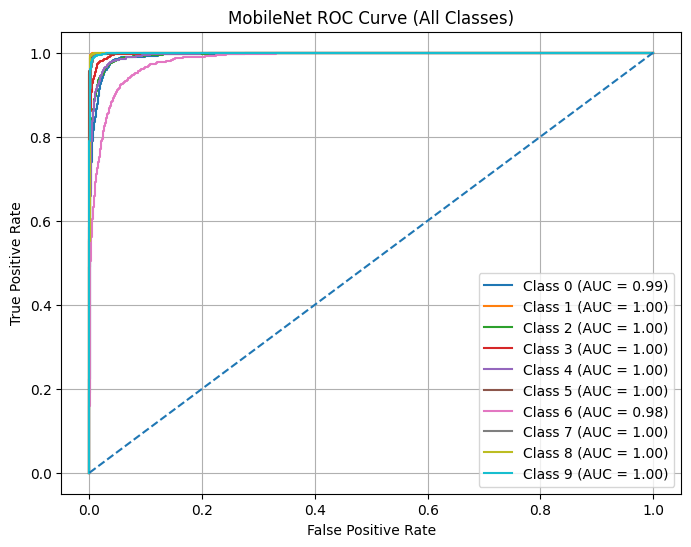

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize the true labels (y_test is available from previous cells)
y_test_bin = label_binarize(y_test, classes=range(10))

# Compute ROC curve and ROC area for each class (y_pred_probs is available)
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(10):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8,6))

for i in range(10):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

# Random classifier line
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("MobileNet ROC Curve (All Classes)")
plt.legend(loc="lower right")
plt.grid()
plt.show()

# ResNet50 with Pretrained weights Buts its Underfitting

In [ ]:

# import tensorflow as tf
# from tensorflow.keras import layers, models
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt

# from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# from sklearn.metrics import roc_curve, auc
# from sklearn.preprocessing import label_binarize

# from google.colab import drive
# drive.mount('/content/drive', force_remount=True)

# train_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Fashion_MNIST/fashion-mnist_train.csv")
# test_df  = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Fashion_MNIST/fashion-mnist_test.csv")

# y_train = train_df.iloc[:, 0].values
# x_train = train_df.iloc[:, 1:].values

# y_test = test_df.iloc[:, 0].values
# x_test = test_df.iloc[:, 1:].values

# # ==============================
# # 3. NORMALIZE + RESHAPE
# # ==============================
# x_train = x_train.astype("float32") / 255.0
# x_test  = x_test.astype("float32") / 255.0

# x_train = x_train.reshape(-1, 28, 28, 1)
# x_test  = x_test.reshape(-1, 28, 28, 1)

# # ==============================
# # 4. ONE-HOT ENCODING
# # ==============================
# y_train_cat = tf.keras.utils.to_categorical(y_train, 10)
# y_test_cat  = tf.keras.utils.to_categorical(y_test, 10)

# # ==============================
# # 5. PREPROCESS
# # ==============================
# def preprocess(image, label):
#     image = tf.image.resize(image, (32, 32))
#     image = tf.image.grayscale_to_rgb(image)
#     return image, label

# # ==============================
# # 6. LIGHT AUGMENTATION
# # ==============================
# def augment(image, label):
#     image = tf.image.random_flip_left_right(image)
#     return image, label

# # ==============================
# # 7. DATA PIPELINE
# # ==============================
# train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train_cat))

# train_ds = (
#     train_ds
#     .shuffle(10000)
#     .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
#     .map(augment, num_parallel_calls=tf.data.AUTOTUNE)
#     .batch(32)
#     .cache()
#     .prefetch(tf.data.AUTOTUNE)
# )

# test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test_cat))

# test_ds = (
#     test_ds
#     .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
#     .batch(32)
#     .cache()
#     .prefetch(tf.data.AUTOTUNE)
# )

# # ==============================
# # 8. RESNET MODEL
# # ==============================
# from tensorflow.keras.applications import ResNet50

# def resnet_fast(input_shape=(32,32,3), num_classes=10):

#     base_model = ResNet50(
#         weights='imagenet',        # pretrained
#         include_top=False,
#         input_shape=input_shape
#     )

#     # freeze most layers
#     for layer in base_model.layers:
#         layer.trainable = False

#     model = models.Sequential([
#         base_model,
#         layers.GlobalAveragePooling2D(),
#         layers.Dense(64, activation='relu'),
#         layers.BatchNormalization(),
#         layers.Dropout(0.3),
#         layers.Dense(num_classes, activation='softmax')
#     ])

#     return model

# model = resnet_fast()

# # ==============================
# # 9. COMPILE
# # ==============================
# model.compile(
#     optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
#     loss='categorical_crossentropy',
#     metrics=['accuracy']
# )

# # ==============================
# # 10. TRAIN (FAST)
# # ==============================
# history = model.fit(
#     train_ds,
#     epochs=5,   # reduced epochs
#     validation_data=test_ds
# )

# # ==============================
# # 11. EVALUATE
# # ==============================
# test_loss, test_acc = model.evaluate(test_ds)
# print("Test Accuracy:", test_acc)

Mounted at /content/drive
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 316s 161ms/step - accuracy: 0.7123 - loss: 0.8267 - val_accuracy: 0.5709 - val_loss: 1.3950
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 315s 157ms/step - accuracy: 0.7548 - loss: 0.6914 - val_accuracy: 0.6867 - val_loss: 0.8884
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 292s 156ms/step - accuracy: 0.7663 - loss: 0.6593 - val_accuracy: 0.6011 - val_loss: 1.4079
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 321s 155ms/step - accuracy: 0.7729 - loss: 0.6425 - val_accuracy: 0.6165 - val_loss: 1.2284
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 292s 156ms/step - accuracy: 0.7763 - loss: 0.6283 - val_accuracy: 0.4580 - val_loss: 1.9842
313/313 ━━━━━━━━━━━━━━━━━━━━ 40s 128ms/step - accuracy: 0.4580 - loss: 1.9842
Test Accuracy: 0.4580000042915344


# ResNet
Residual learning

BatchNorm everywhere → faster convergence
Dropout → prevents overfitting
Class weights → handles imbalance
Adaptive LR → better training
Early stopping → avoids overtraining

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

train_path = "/content/drive/MyDrive/Colab Notebooks/Fashion_MNIST/fashion-mnist_train.csv"
test_path = "/content/drive/MyDrive/Colab Notebooks/Fashion_MNIST/fashion-mnist_test.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)


# PREPROCESS DATA

X = train_df.drop("label", axis=1).values
y = train_df["label"].values

# Normalize
X = X / 255.0

# Reshape (32x32)
X = X.reshape(-1, 28, 28, 1)
X = tf.image.resize(X, (32, 32)).numpy()

# One-hot encode
y_encoded = to_categorical(y, 10)

# Train-validation split
X_train, X_val, y_train, y_val = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42
)


# CLASS WEIGHTS

y_train_labels = np.argmax(y_train, axis=1)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_labels),
    y=y_train_labels
)

class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)


# RESNET BLOCK

def res_block(x, filters, stride=1):
    shortcut = x

    x = layers.Conv2D(filters, (3,3), strides=stride, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(filters, (3,3), padding='same')(x)
    x = layers.BatchNormalization()(x)

    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, (1,1), strides=stride, padding='same')(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.ReLU()(x)

    return x


# BUILD RESNET MODEL

def build_resnet():
    inputs = layers.Input(shape=(32, 32, 1))

    x = layers.Conv2D(32, (3,3), padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = res_block(x, 32)
    x = res_block(x, 32)

    x = res_block(x, 64, stride=2)
    x = res_block(x, 64)

    x = res_block(x, 128, stride=2)
    x = res_block(x, 128)

    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(128, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(10, activation='softmax')(x)

    model = models.Model(inputs, outputs)
    return model

model = build_resnet()


# COMPILE MODEL

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


# CALLBACKS

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-5
)


# TRAIN MODEL

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stop, lr_scheduler]
)


# PREPARE TEST DATA

X_test = test_df.drop("label", axis=1).values / 255.0
X_test = X_test.reshape(-1, 28, 28, 1)
X_test = tf.image.resize(X_test, (32, 32)).numpy()

y_test = test_df["label"].values
y_test_encoded = to_categorical(y_test, 10)

test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test_encoded))
test_ds = test_ds.batch(32).cache().prefetch(tf.data.AUTOTUNE)


# PREDICT
preds = model.predict(X_test)
pred_labels = np.argmax(preds, axis=1)

Class Weights: {0: np.float64(1.0067114093959733), 1: np.float64(0.9946125155408205), 2: np.float64(1.0), 3: np.float64(1.008827238335435), 4: np.float64(0.9968847352024922), 5: np.float64(0.9878575838649928), 6: np.float64(1.0090393104898046), 7: np.float64(1.0050251256281406), 8: np.float64(0.9894867037724181), 9: np.float64(1.0020876826722338)}


Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_11      │ (None, 32, 32, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_39 (Conv2D)  │ (None, 32, 32,    │        320 │ input_layer_11[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_39[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_32 (ReLU)     │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_40 (Conv2D)  │ (None, 32, 32,    │      9,248 │ re_lu_32[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_40[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_33 (ReLU)     │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_41 (Conv2D)  │ (None, 32, 32,    │      9,248 │ re_lu_33[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_41[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │ re_lu_32[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_34 (ReLU)     │ (None, 32, 32,    │          0 │ add_6[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_42 (Conv2D)  │ (None, 32, 32,    │      9,248 │ re_lu_34[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_42[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_35 (ReLU)     │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_43 (Conv2D)  │ (None, 32, 32,    │      9,248 │ re_lu_35[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_43[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_7 (Add)         │ (None, 32, 32,    │          0 │ batch_normalizat

 Total params: 716,426 (2.73 MB)

 Trainable params: 713,930 (2.72 MB)

 Non-trainable params: 2,496 (9.75 KB)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1220s 802ms/step - accuracy: 0.8054 - loss: 0.5541 - val_accuracy: 0.8527 - val_loss: 0.4361 - learning_rate: 0.0010
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1237s 812ms/step - accuracy: 0.8853 - loss: 0.3309 - val_accuracy: 0.7163 - val_loss: 0.8263 - learning_rate: 0.0010
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1206s 804ms/step - accuracy: 0.9020 - loss: 0.2832 - val_accuracy: 0.8851 - val_loss: 0.3281 - learning_rate: 0.0010
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1210s 807ms/step - accuracy: 0.9151 - loss: 0.2445 - val_accuracy: 0.8991 - val_loss: 0.2731 - learning_rate: 0.0010
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1221s 814ms/step - accuracy: 0.9218 - loss: 0.2245 - val_accuracy: 0.9134 - val_loss: 0.2442 - learning_rate: 0.0010
313/313 ━━━━━━━━━━━━━━━━━━━━ 59s 187ms/step


In [ ]:
# EVALUATE

test_loss, test_acc = model.evaluate(test_ds)
print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 59s 187ms/step - accuracy: 0.9223 - loss: 0.2300
Test Accuracy: 0.9222999811172485


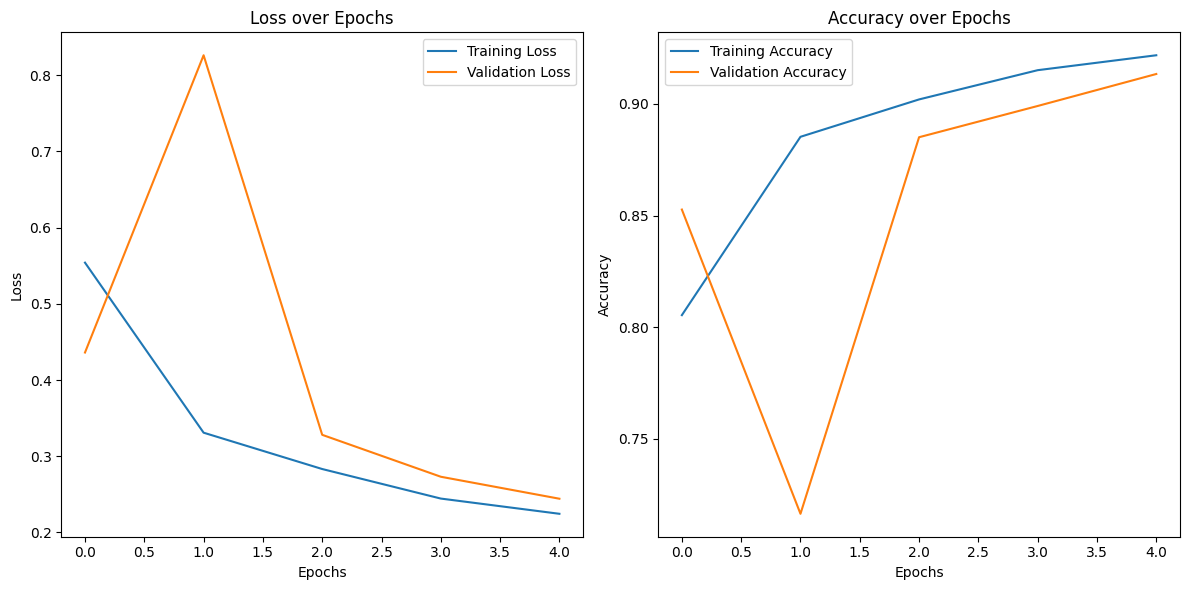

In [ ]:
# Extract loss and accuracy for training and validation
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

# Plotting Loss
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)  # Create a subplot for loss
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plotting Accuracy
plt.subplot(1, 2, 2)  # Create a subplot for accuracy
plt.plot(train_accuracy, label='Training Accuracy')
plt.plot(val_accuracy, label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Display the plots
plt.tight_layout()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 59s 186ms/step


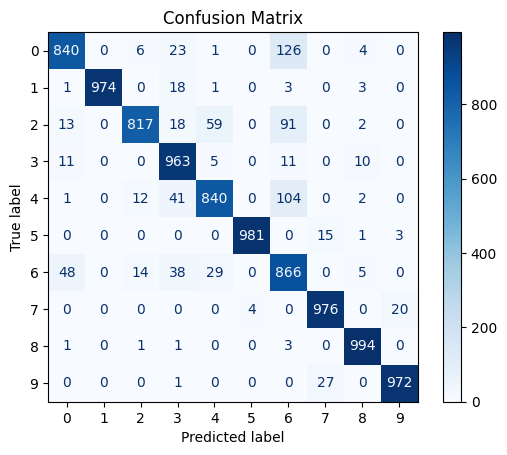

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)


# CONFUSION MATRIX

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

plt.title("Confusion Matrix")
plt.show()

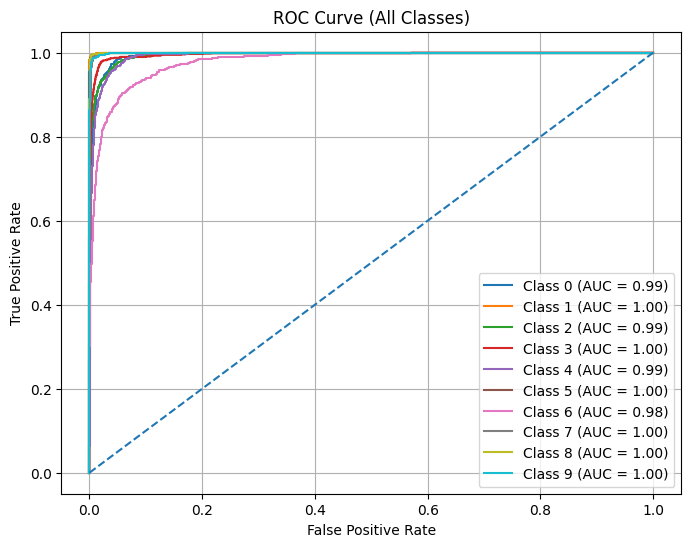

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# ROC CURVE (ALL CLASSES)

y_test_bin = label_binarize(y_test, classes=np.arange(10))

fpr, tpr, roc_auc = {}, {}, {}

for i in range(10):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8,6))

for i in range(10):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (All Classes)")
plt.legend()
plt.grid()
plt.show()

# Efficient Net

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

train_path = "/content/drive/MyDrive/Colab Notebooks/Fashion_MNIST/fashion-mnist_train.csv"
test_path = "/content/drive/MyDrive/Colab Notebooks/Fashion_MNIST/fashion-mnist_test.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)


# PREPROCESS DATA

X = train_df.drop("label", axis=1).values
y = train_df["label"].values

# Normalize
X = X / 255.0

# Reshape (32x32)
X = X.reshape(-1, 28, 28, 1)
X = tf.image.resize(X, (32, 32)).numpy()

# One-hot encode
y_encoded = to_categorical(y, 10)

# Train-validation split
X_train, X_val, y_train, y_val = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42
)


# CLASS WEIGHTS

y_train_labels = np.argmax(y_train, axis=1)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_labels),
    y=y_train_labels
)

class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)


# MBConv BLOCK (EfficientNet Block)

def mbconv_block(x, out_channels, expansion=4, stride=1):
    in_channels = x.shape[-1]

    # Expansion
    expanded = layers.Conv2D(in_channels * expansion, (1,1), padding='same')(x)
    expanded = layers.BatchNormalization()(expanded)
    expanded = layers.ReLU()(expanded)

    # Depthwise Convolution
    dw = layers.DepthwiseConv2D((3,3), strides=stride, padding='same')(expanded)
    dw = layers.BatchNormalization()(dw)
    dw = layers.ReLU()(dw)

    # Projection
    projected = layers.Conv2D(out_channels, (1,1), padding='same')(dw)
    projected = layers.BatchNormalization()(projected)

    # Skip connection
    if stride == 1 and in_channels == out_channels:
        projected = layers.Add()([x, projected])

    return projected


# BUILD EFFICIENTNET MODEL

def build_efficientnet():
    inputs = layers.Input(shape=(32, 32, 1))

    # Stem
    x = layers.Conv2D(32, (3,3), padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # Blocks
    x = mbconv_block(x, 32, expansion=1)
    x = mbconv_block(x, 32)

    x = mbconv_block(x, 64, stride=2)
    x = mbconv_block(x, 64)

    x = mbconv_block(x, 128, stride=2)
    x = mbconv_block(x, 128)

    # Head
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(128, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(10, activation='softmax')(x)

    model = models.Model(inputs, outputs)
    return model

model = build_efficientnet()


# COMPILE MODEL

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


# CALLBACKS

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-5
)


# TRAIN MODEL

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stop, lr_scheduler],
    shuffle=True
)


# PREPARE TEST DATA

X_test = test_df.drop("label", axis=1).values / 255.0
X_test = X_test.reshape(-1, 28, 28, 1)
X_test = tf.image.resize(X_test, (32, 32)).numpy()

y_test = test_df["label"].values
y_test_encoded = to_categorical(y_test, 10)

test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test_encoded))
test_ds = test_ds.batch(32).cache().prefetch(tf.data.AUTOTUNE)

Class Weights: {0: np.float64(1.0067114093959733), 1: np.float64(0.9946125155408205), 2: np.float64(1.0), 3: np.float64(1.008827238335435), 4: np.float64(0.9968847352024922), 5: np.float64(0.9878575838649928), 6: np.float64(1.0090393104898046), 7: np.float64(1.0050251256281406), 8: np.float64(0.9894867037724181), 9: np.float64(1.0020876826722338)}


Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_13      │ (None, 32, 32, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 32, 32,    │        320 │ input_layer_13[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_23[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_6 (ReLU)      │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (None, 32, 32,    │      1,056 │ re_lu_6[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_24[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_7 (ReLU)      │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d    │ (None, 32, 32,    │        320 │ re_lu_7[0][0]     │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ depthwise_conv2d… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_8 (ReLU)      │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_25 (Conv2D)  │ (None, 32, 32,    │      1,056 │ re_lu_8[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_25[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 32, 32,    │          0 │ re_lu_6[0][0],    │
│                     │ 32)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_26 (Conv2D)  │ (None, 32, 32,    │      4,224 │ add[0][0]         │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        512 │ conv2d_26[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_9 (ReLU)      │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d_1  │ (None, 32, 32,    │      1,280 │ re_lu_9[0][0]   

 Total params: 281,450 (1.07 MB)

 Trainable params: 274,986 (1.05 MB)

 Non-trainable params: 6,464 (25.25 KB)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 61s 20ms/step - accuracy: 0.7961 - loss: 0.5986 - val_accuracy: 0.8111 - val_loss: 0.6221 - learning_rate: 0.0010
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 26s 18ms/step - accuracy: 0.8780 - loss: 0.3491 - val_accuracy: 0.8675 - val_loss: 0.3845 - learning_rate: 0.0010
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - accuracy: 0.8952 - loss: 0.3030 - val_accuracy: 0.7632 - val_loss: 0.7344 - learning_rate: 0.0010
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 25s 17ms/step - accuracy: 0.9026 - loss: 0.2803 - val_accuracy: 0.8908 - val_loss: 0.3068 - learning_rate: 0.0010
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 25s 17ms/step - accuracy: 0.9090 - loss: 0.2588 - val_accuracy: 0.8914 - val_loss: 0.3026 - learning_rate: 0.0010
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - accuracy: 0.9161 - loss: 0.2429 - val_accuracy: 0.8836 - val_loss: 0.3144 - learning_rate: 0.0010
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - accura

In [ ]:
# EVALUATE

test_loss, test_acc = model.evaluate(test_ds)
print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 28ms/step - accuracy: 0.9119 - loss: 0.2490
Test Accuracy: 0.911899983882904


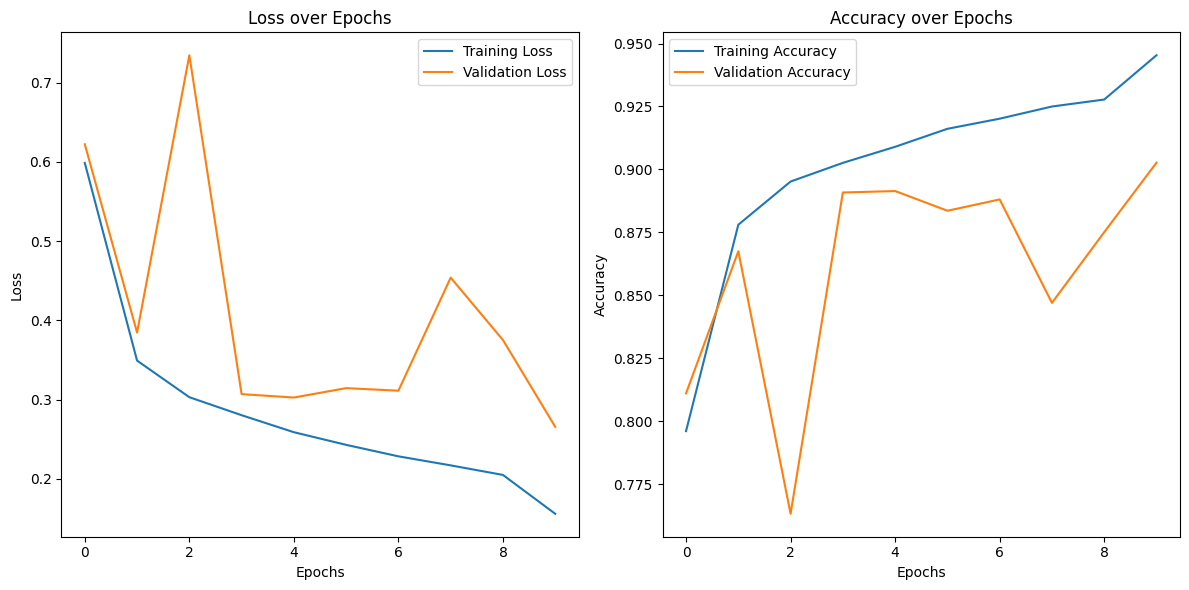

In [ ]:
# Extract loss and accuracy for training and validation
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

# Plotting Loss
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)  # Create a subplot for loss
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plotting Accuracy
plt.subplot(1, 2, 2)  # Create a subplot for accuracy
plt.plot(train_accuracy, label='Training Accuracy')
plt.plot(val_accuracy, label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Display the plots
plt.tight_layout()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step


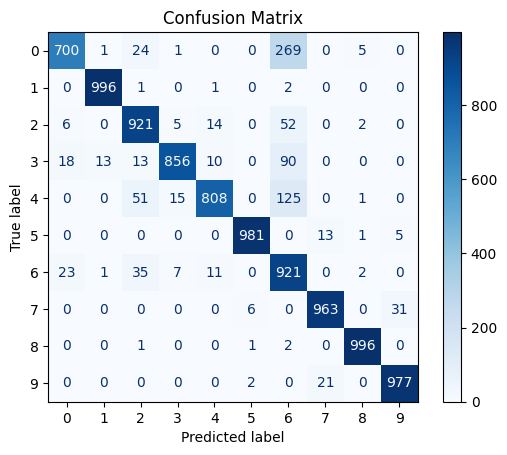

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)


# CONFUSION MATRIX

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

plt.title("Confusion Matrix")
plt.show()

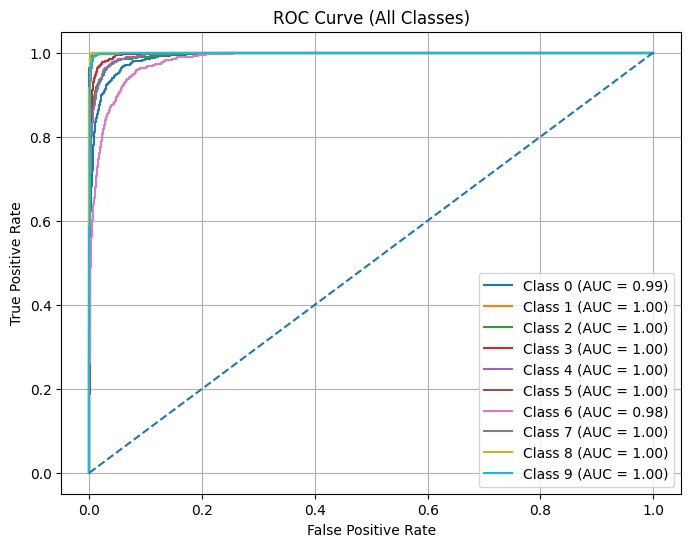

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# ROC CURVE (ALL CLASSES)

y_test_bin = label_binarize(y_test, classes=np.arange(10))

fpr, tpr, roc_auc = {}, {}, {}

for i in range(10):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8,6))

for i in range(10):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (All Classes)")
plt.legend()
plt.grid()
plt.show()

# ConvNeX

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

train_path = "/content/drive/MyDrive/Colab Notebooks/Fashion_MNIST/fashion-mnist_train.csv"
test_path = "/content/drive/MyDrive/Colab Notebooks/Fashion_MNIST/fashion-mnist_test.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)


# PREPROCESS

X = train_df.drop("label", axis=1).values
y = train_df["label"].values

X = X / 255.0
X = X.reshape(-1, 28, 28, 1)
X = tf.image.resize(X, (32, 32)).numpy()

y_encoded = to_categorical(y, 10)

X_train, X_val, y_train, y_val = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42
)


# DATA AUGMENTATION

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])


# CLASS WEIGHTS

y_train_labels = np.argmax(y_train, axis=1)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_labels),
    y=y_train_labels
)
class_weights = dict(enumerate(class_weights))


# IMPROVED CONVNEXT BLOCK

def convnext_block(x, dim):
    shortcut = x

    x = layers.DepthwiseConv2D(7, padding='same')(x)
    x = layers.LayerNormalization(epsilon=1e-6)(x)

    x = layers.Conv2D(4 * dim, kernel_size=1)(x) # Apply Conv2D to x
    x = layers.ReLU()(x)

    x = layers.Conv2D(dim, kernel_size=1)(x) # Apply Conv2D to x

    x = layers.Add()([shortcut, x])
    return x


# BUILD MODEL

def build_model():
    inputs = layers.Input(shape=(32, 32, 1))

    # Apply augmentation INSIDE model
    x = data_augmentation(inputs)

    # Stem
    x = layers.Conv2D(64, 4, strides=4, padding='same')(x)
    x = layers.LayerNormalization(epsilon=1e-6)(x)

    # Stage 1
    for _ in range(3):   # increased depth
        x = convnext_block(x, 64)

    # Downsample
    x = layers.Conv2D(128, 2, strides=2)(x)

    # Stage 2
    for _ in range(3):
        x = convnext_block(x, 128)

    # Downsample
    x = layers.Conv2D(256, 2, strides=2)(x)

    # Stage 3
    for _ in range(3):
        x = convnext_block(x, 256)

    # Head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(10, activation='softmax')(x)

    return models.Model(inputs, outputs)

model = build_model()


# LEARNING RATE TUNING

optimizer = tf.keras.optimizers.Adam(learning_rate=3e-4)  # tuned

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


# CALLBACKS

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-5
)


# TRAIN (Batch size tuned)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=25,
    batch_size=64,
    class_weight=class_weights,
    callbacks=[early_stop, lr_scheduler],
    shuffle=True
)


# TEST DATA

X_test = test_df.drop("label", axis=1).values / 255.0
X_test = X_test.reshape(-1, 28, 28, 1)
X_test = tf.image.resize(X_test, (32, 32)).numpy()

y_test = test_df["label"].values
y_test_encoded = to_categorical(y_test, 10)

test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test_encoded))
test_ds = test_ds.batch(64).cache().prefetch(tf.data.AUTOTUNE)


# EVALUATE

test_loss, test_acc = model.evaluate(test_ds)
print("Test Accuracy:", test_acc)

Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_14      │ (None, 32, 32, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_10       │ (None, 32, 32, 1) │          0 │ input_layer_14[0… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_36 (Conv2D)  │ (None, 8, 8, 64)  │      1,088 │ sequential_10[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 8, 8, 64)  │        128 │ conv2d_36[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d_6  │ (None, 8, 8, 64)  │      3,200 │ layer_normalizat… │
│ (DepthwiseConv2D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 8, 8, 64)  │        128 │ depthwise_conv2d… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_37 (Conv2D)  │ (None, 8, 8, 256) │     16,640 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_19 (ReLU)     │ (None, 8, 8, 256) │          0 │ conv2d_37[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_38 (Conv2D)  │ (None, 8, 8, 64)  │     16,448 │ re_lu_19[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 8, 8, 64)  │          0 │ layer_normalizat… │
│                     │                   │            │ conv2d_38[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d_7  │ (None, 8, 8, 64)  │      3,200 │ add_4[0][0]       │
│ (DepthwiseConv2D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 8, 8, 64)  │        128 │ depthwise_conv2d… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_39 (Conv2D)  │ (None, 8, 8, 256) │     16,640 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_20 (ReLU)     │ (None, 8, 8, 256) │          0 │ conv2d_39[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_40 (Conv2D)  │ (None, 8, 8, 64)  │     16,448 │ re_lu_20[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 8, 8, 64)  │          0 │ add_4[0][0],      │
│                     │                   │            │ conv2d_40[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d_8  │ (None, 8, 8, 64)  │      3,200 │ add_5[0][0]       │
│ (DepthwiseConv2D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 8, 8, 64)  │        128 │ depthwise_conv2d… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_41 (Conv2D)  │ (None, 8, 8, 256) │     16,640 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 2,340,618 (8.93 MB)

 Trainable params: 2,340,618 (8.93 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
750/750 ━━━━━━━━━━━━━━━━━━━━ 47s 40ms/step - accuracy: 0.6650 - loss: 0.9156 - val_accuracy: 0.7513 - val_loss: 0.6305 - learning_rate: 3.0000e-04
Epoch 2/25
750/750 ━━━━━━━━━━━━━━━━━━━━ 30s 41ms/step - accuracy: 0.7757 - loss: 0.6324 - val_accuracy: 0.7928 - val_loss: 0.5719 - learning_rate: 3.0000e-04
Epoch 3/25
750/750 ━━━━━━━━━━━━━━━━━━━━ 40s 39ms/step - accuracy: 0.8008 - loss: 0.5559 - val_accuracy: 0.8117 - val_loss: 0.4840 - learning_rate: 3.0000e-04
Epoch 4/25
750/750 ━━━━━━━━━━━━━━━━━━━━ 29s 39ms/step - accuracy: 0.8177 - loss: 0.5136 - val_accuracy: 0.8310 - val_loss: 0.4534 - learning_rate: 3.0000e-04
Epoch 5/25
750/750 ━━━━━━━━━━━━━━━━━━━━ 29s 39ms/step - accuracy: 0.8261 - loss: 0.4805 - val_accuracy: 0.8367 - val_loss: 0.4365 - learning_rate: 3.0000e-04
Epoch 6/25
750/750 ━━━━━━━━━━━━━━━━━━━━ 29s 39ms/step - accuracy: 0.8342 - loss: 0.4629 - val_accuracy: 0.8247 - val_loss: 0.4464 - learning_rate: 3.0000e-04
Epoch 7/25
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 39ms/ste

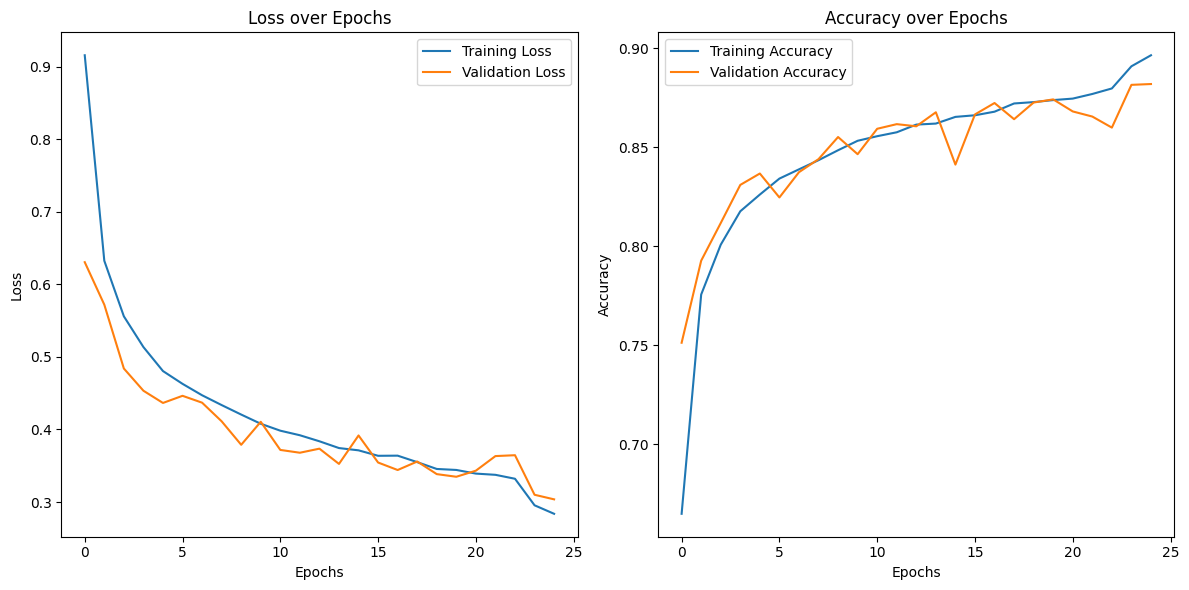

In [ ]:
# Extract loss and accuracy for training and validation
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

# Plotting Loss
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)  # Create a subplot for loss
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plotting Accuracy
plt.subplot(1, 2, 2)  # Create a subplot for accuracy
plt.plot(train_accuracy, label='Training Accuracy')
plt.plot(val_accuracy, label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Display the plots
plt.tight_layout()
plt.show()

157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step


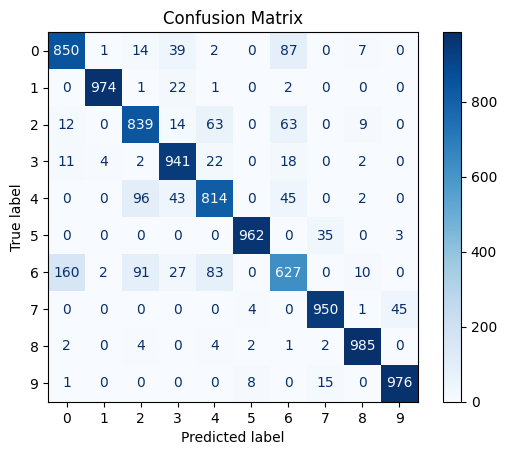

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)


# CONFUSION MATRIX

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

plt.title("Confusion Matrix")
plt.show()

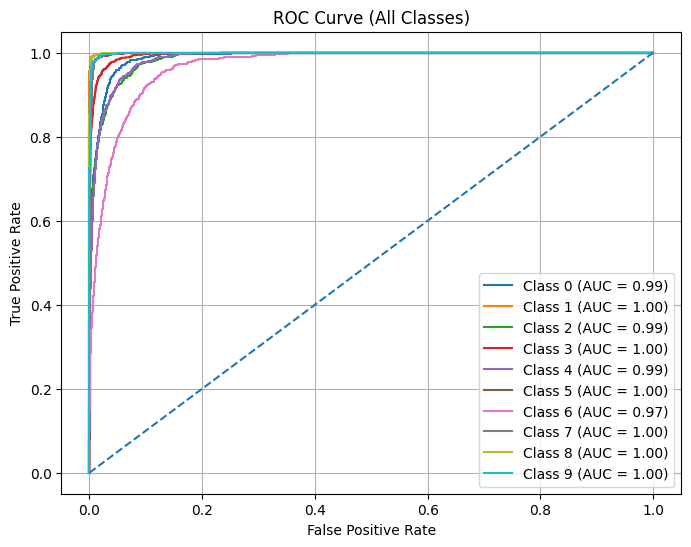

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# ROC CURVE (ALL CLASSES)

y_test_bin = label_binarize(y_test, classes=np.arange(10))

fpr, tpr, roc_auc = {}, {}, {}

for i in range(10):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8,6))

for i in range(10):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (All Classes)")
plt.legend()
plt.grid()
plt.show()

# DenseNet

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

train_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Fashion_MNIST/fashion-mnist_train.csv")
test_df  = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Fashion_MNIST/fashion-mnist_test.csv")

y_train = train_df.iloc[:, 0].values
x_train = train_df.iloc[:, 1:].values

y_test = test_df.iloc[:, 0].values
x_test = test_df.iloc[:, 1:].values


# PREPROCESSING

x_train = x_train.reshape(-1, 28, 28, 1).astype("float32") / 255.0
x_test  = x_test.reshape(-1, 28, 28, 1).astype("float32") / 255.0

y_train_cat = tf.keras.utils.to_categorical(y_train, 10)
y_test_cat  = tf.keras.utils.to_categorical(y_test, 10)


# CLASS WEIGHTS

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights_dict = dict(enumerate(class_weights))
print("Class Weights:", class_weights_dict)

# DATA PIPELINE (WITH SHUFFLE)

def preprocess(image, label):
    image = tf.image.resize(image, (96, 96))
    image = tf.image.grayscale_to_rgb(image)
    return image, label

train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train_cat))
train_ds = train_ds.shuffle(buffer_size=10000)
train_ds = train_ds.map(preprocess).batch(32).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test_cat))
test_ds = test_ds.map(preprocess).batch(32).prefetch(tf.data.AUTOTUNE)


# MODEL (DenseNet)

from tensorflow.keras.applications import DenseNet121

def densenet_model(input_shape=(96,96,3), num_classes=10):
    base_model = DenseNet121(
        weights=None,
        include_top=False,
        input_shape=input_shape
    )

    base_model.trainable = True

    model = models.Sequential([
        base_model,

        layers.GlobalAveragePooling2D(),

        layers.BatchNormalization(),
        layers.Dense(128, activation='relu'),

        layers.BatchNormalization(),
        layers.Dropout(0.4),

        layers.Dense(num_classes, activation='softmax')
    ])
    return model

model = densenet_model()


# COMPILE

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


# CALLBACKS

callbacks = [

    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]


# TRAIN

history = model.fit(
    train_ds,
    epochs=5,
    validation_data=test_ds,
    class_weight=class_weights_dict,
    callbacks=callbacks,
    shuffle=True
)

Mounted at /content/drive
Class Weights: {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.0), 4: np.float64(1.0), 5: np.float64(1.0), 6: np.float64(1.0), 7: np.float64(1.0), 8: np.float64(1.0), 9: np.float64(1.0)}


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 3, 3, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_44          │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_45          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,174,602 (27.37 MB)

 Trainable params: 7,088,650 (27.04 MB)

 Non-trainable params: 85,952 (335.75 KB)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 350s 97ms/step - accuracy: 0.8247 - loss: 0.4972 - val_accuracy: 0.8738 - val_loss: 0.3365 - learning_rate: 0.0010
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 158s 84ms/step - accuracy: 0.8878 - loss: 0.3163 - val_accuracy: 0.8281 - val_loss: 0.4818 - learning_rate: 0.0010
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.8967 - loss: 0.2869
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 161s 86ms/step - accuracy: 0.8990 - loss: 0.2804 - val_accuracy: 0.8613 - val_loss: 0.3623 - learning_rate: 0.0010
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 158s 84ms/step - accuracy: 0.9273 - loss: 0.2031 - val_accuracy: 0.9326 - val_loss: 0.1795 - learning_rate: 3.0000e-04
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 158s 84ms/step - accuracy: 0.9335 - loss: 0.1844 - val_accuracy: 0.9343 - val_loss: 0.1861 - learning_rate: 3.0000e-04


In [ ]:
# EVALUATE

test_loss, test_acc = model.evaluate(test_ds)
print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - accuracy: 0.9326 - loss: 0.1795
Test Accuracy: 0.9326000213623047


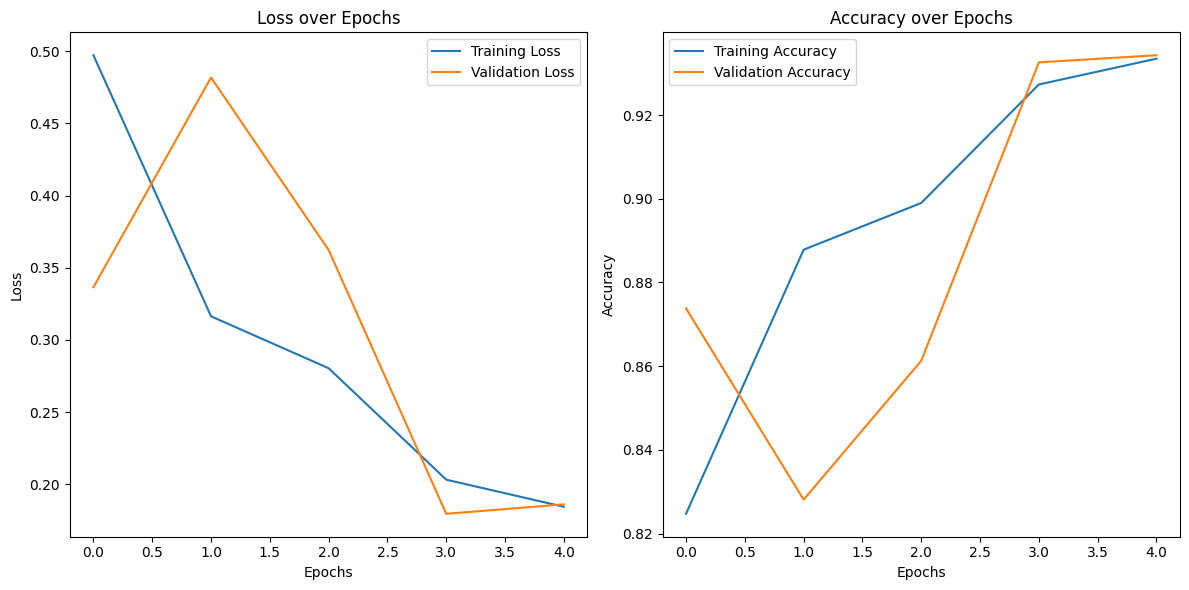

In [ ]:
# Extract loss and accuracy for training and validation
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

# Plotting Loss
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)  # Create a subplot for loss
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plotting Accuracy
plt.subplot(1, 2, 2)  # Create a subplot for accuracy
plt.plot(train_accuracy, label='Training Accuracy')
plt.plot(val_accuracy, label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Display the plots
plt.tight_layout()
plt.show()

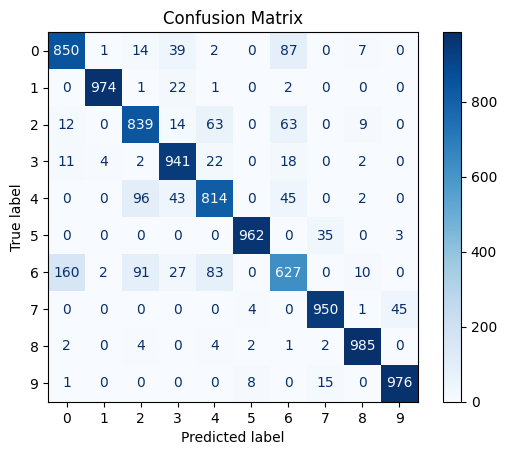

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# CONFUSION MATRIX

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

plt.title("Confusion Matrix")
plt.show()

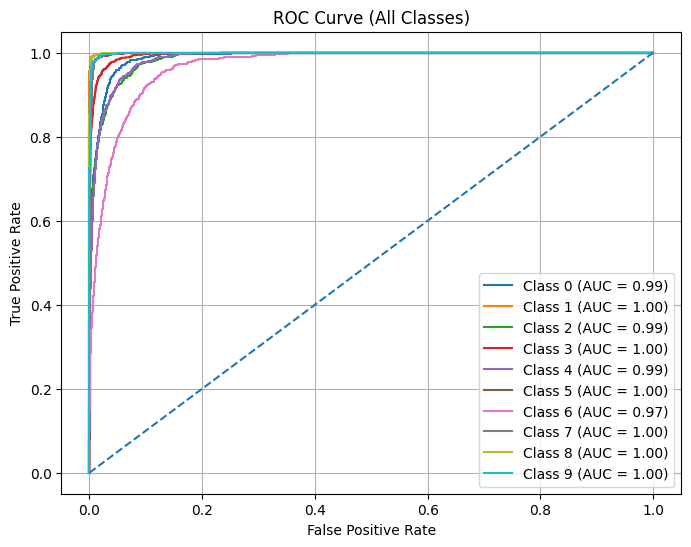

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# ROC CURVE (ALL CLASSES)

y_test_bin = label_binarize(y_test, classes=np.arange(10))

fpr, tpr, roc_auc = {}, {}, {}

for i in range(10):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8,6))

for i in range(10):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (All Classes)")
plt.legend()
plt.grid()
plt.show()

# VGG16

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.utils.class_weight import compute_class_weight


train_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Fashion_MNIST/fashion-mnist_train.csv")
test_df  = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Fashion_MNIST/fashion-mnist_test.csv")

# First column = label
y_train = train_df.iloc[:, 0].values
X_train = train_df.iloc[:, 1:].values

y_test = test_df.iloc[:, 0].values
X_test = test_df.iloc[:, 1:].values


# ==============================
# PREPROCESSING
# ==============================
X_train = X_train / 255.0
X_test  = X_test / 255.0

X_train = X_train.reshape(-1, 28, 28, 1)
X_test  = X_test.reshape(-1, 28, 28, 1)

y_train_labels = y_train.copy()

y_train_encoded = to_categorical(y_train, 10)
y_test_encoded  = to_categorical(y_test, 10)


# ==============================
# CLASS WEIGHTS
# ==============================
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_labels),
    y=y_train_labels
)

class_weights_dict = dict(enumerate(class_weights))
print("Class Weights:", class_weights_dict)


# ==============================
# DATA AUGMENTATION
# ==============================
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=False   # clothes flipping may change meaning
)

datagen.fit(X_train)


# ==============================
# VGG16 MODEL
# ==============================
model = models.Sequential([

    # Block 1
    layers.Conv2D(64, (3,3), padding='same', activation='relu', input_shape=(28,28,1)),
    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),

    # Block 2
    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),

    # Block 3
    layers.Conv2D(256, (3,3), padding='same', activation='relu'),
    layers.Conv2D(256, (3,3), padding='same', activation='relu'),
    layers.Conv2D(256, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),

    # Block 4
    layers.Conv2D(512, (3,3), padding='same', activation='relu'),
    layers.Conv2D(512, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),

    # Fully Connected
    layers.Flatten(),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(10, activation='softmax')
])


# ==============================
# COMPILE
# ==============================
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


# ==============================
# CALLBACKS
# ==============================
callbacks = [

    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=2,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=2,
        min_lr=1e-5,
        verbose=1
    )
]


# ==============================
# TRAIN WITH AUGMENTATION
# ==============================
history = model.fit(
    datagen.flow(X_train, y_train_encoded, batch_size=32),
    epochs=10,
    validation_data=(X_test, y_test_encoded),
    class_weight=class_weights_dict,
    callbacks=callbacks,
    steps_per_epoch=len(X_train)//32,
    shuffle=True

)

Class Weights: {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.0), 4: np.float64(1.0), 5: np.float64(1.0), 6: np.float64(1.0), 7: np.float64(1.0), 8: np.float64(1.0), 9: np.float64(1.0)}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 7, 7, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 3, 3, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 1, 1, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,439,818 (20.75 MB)

 Trainable params: 5,439,818 (20.75 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 49s 21ms/step - accuracy: 0.6025 - loss: 1.0237 - val_accuracy: 0.7982 - val_loss: 0.4975 - learning_rate: 0.0010
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 36s 19ms/step - accuracy: 0.7911 - loss: 0.5616 - val_accuracy: 0.8352 - val_loss: 0.4322 - learning_rate: 0.0010
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 19ms/step - accuracy: 0.8296 - loss: 0.4721 - val_accuracy: 0.8629 - val_loss: 0.3793 - learning_rate: 0.0010
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 35s 19ms/step - accuracy: 0.8483 - loss: 0.4269 - val_accuracy: 0.8753 - val_loss: 0.3235 - learning_rate: 0.0010
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 35s 19ms/step - accuracy: 0.8576 - loss: 0.3995 - val_accuracy: 0.8845 - val_loss: 0.3011 - learning_rate: 0.0010
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 35s 19ms/step - accuracy: 0.8626 - loss: 0.3872 - val_accuracy: 0.8938 - val_loss: 0.2858 - learning_rate: 0.0010
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 35s 18ms/step - accura

In [ ]:
# EVALUATE

test_loss, test_acc = model.evaluate(X_test, y_test_encoded)
print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9004 - loss: 0.2753
Test Accuracy: 0.9003999829292297


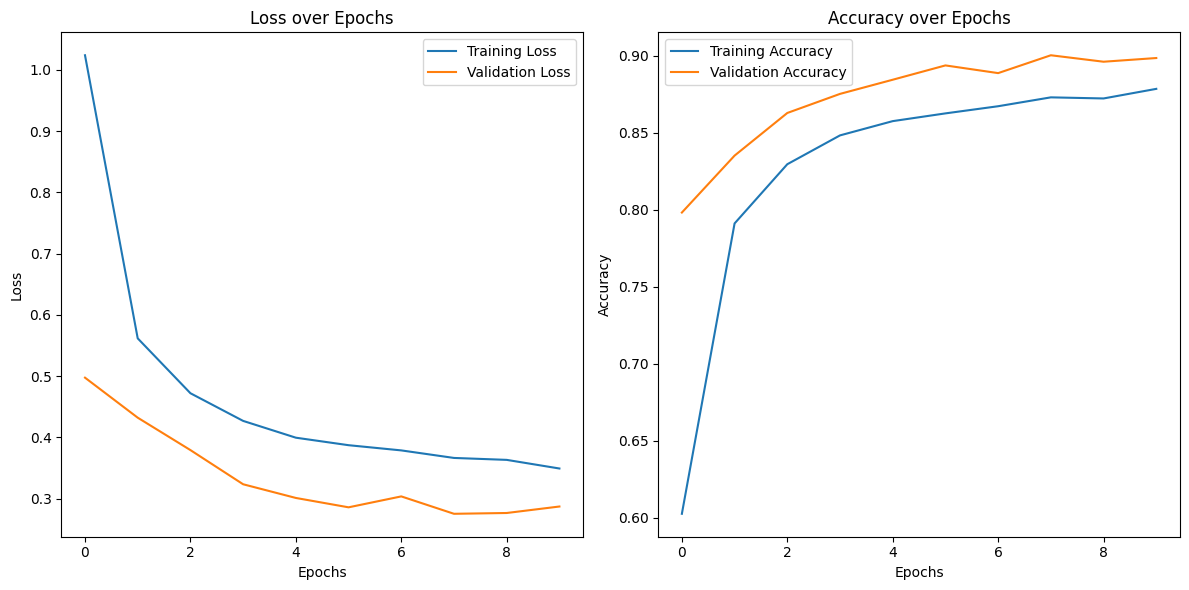

In [ ]:
# Extract loss and accuracy for training and validation
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

# Plotting Loss
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)  # Create a subplot for loss
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plotting Accuracy
plt.subplot(1, 2, 2)  # Create a subplot for accuracy
plt.plot(train_accuracy, label='Training Accuracy')
plt.plot(val_accuracy, label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Display the plots
plt.tight_layout()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


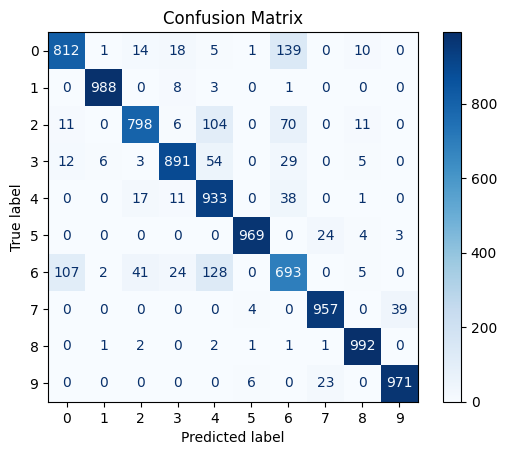

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import numpy as np

# Make predictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# CONFUSION MATRIX

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

plt.title("Confusion Matrix")
plt.show()

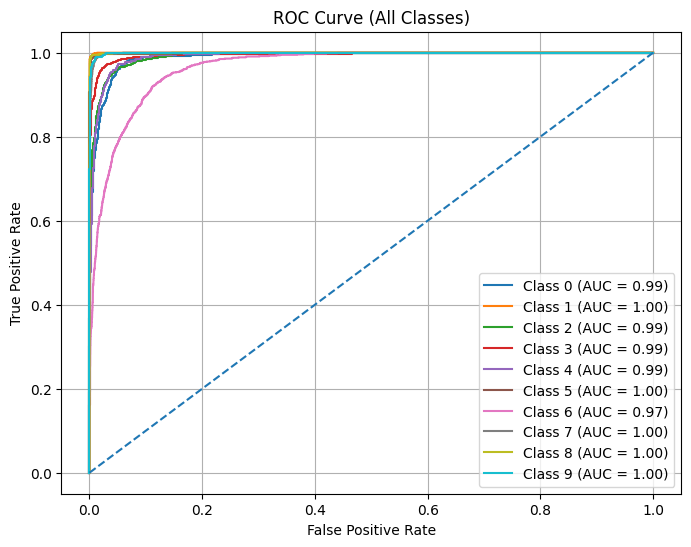

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# ROC CURVE (ALL CLASSES)

y_test_bin = label_binarize(y_test, classes=np.arange(10))

fpr, tpr, roc_auc = {}, {}, {}

for i in range(10):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8,6))

for i in range(10):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (All Classes)")
plt.legend()
plt.grid()
plt.show()